# **WEEK 2 - KNOW YOUR DATA**

The objective is to understand and gain domain knowledge about the problem statement, and explore the chosen dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

# Upload file from your computer
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv('2017_dataset.csv')
print(df.info()) # to identify data types and columns
print(df.describe()) #to understand the summary statistics of the given dataset
#To understand the data

Saving 2017_dataset.csv to 2017_dataset.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FL_DATE              200000 non-null  object 
 1   OP_CARRIER           200000 non-null  object 
 2   OP_CARRIER_FL_NUM    200000 non-null  int64  
 3   ORIGIN               200000 non-null  object 
 4   DEST                 200000 non-null  object 
 5   CRS_DEP_TIME         200000 non-null  int64  
 6   DEP_TIME             197193 non-null  float64
 7   DEP_DELAY            197192 non-null  float64
 8   TAXI_OUT             197121 non-null  float64
 9   WHEELS_OFF           197121 non-null  float64
 10  WHEELS_ON            197032 non-null  float64
 11  TAXI_IN              197032 non-null  float64
 12  CRS_ARR_TIME         200000 non-null  int64  
 13  ARR_TIME             197032 non-null  float64
 14  ARR_DELAY            196

# **WEEK 3 - THE CLEANING SPRINT**

The objective is to engineer the dataset and clean it by handling missing values and detecting outliers.

**MISSING VALUES DETECTION:**

In this code cell, missing values are identified in the given dataset using the `isnull().sum()` function call. After identifying missing values, it is visualized using a bar chart, representing the comparison of missing values per category


MISSING VALUES DETECTION
Columns with missing values:
             Column  Missing_Count
        Unnamed: 27         200000
  CANCELLATION_CODE         197103
      CARRIER_DELAY         163716
LATE_AIRCRAFT_DELAY         163716
          NAS_DELAY         163716
      WEATHER_DELAY         163716
     SECURITY_DELAY         163716
ACTUAL_ELAPSED_TIME           3332
          ARR_DELAY           3332
           AIR_TIME           3332
            TAXI_IN           2968
           ARR_TIME           2968
          WHEELS_ON           2968
         WHEELS_OFF           2879
           TAXI_OUT           2879
          DEP_DELAY           2808
           DEP_TIME           2807




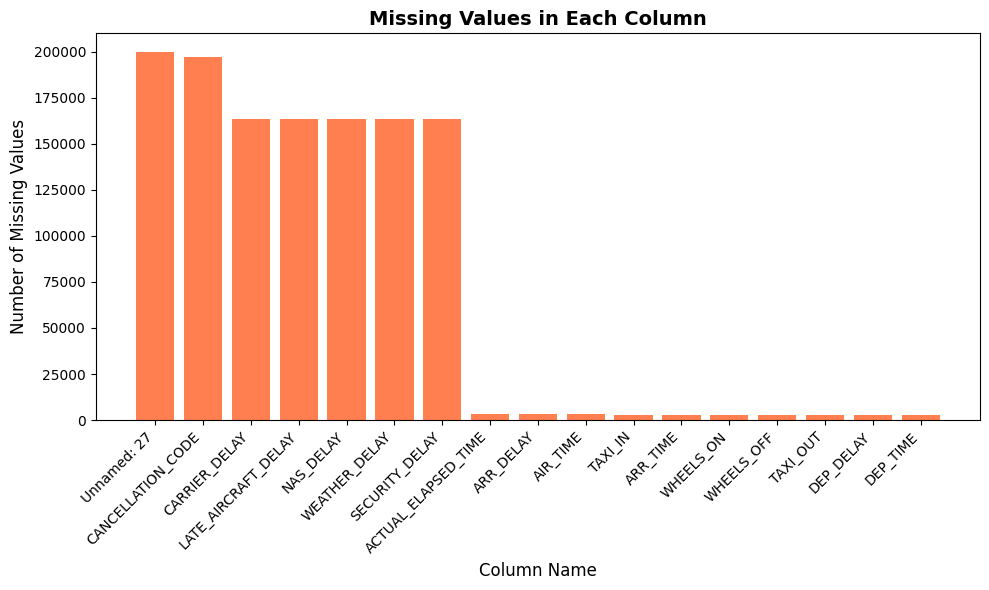

In [3]:
print("MISSING VALUES DETECTION")

# Count missing values in each column
missing_count = df.isnull().sum()

# Create summary table
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_count.values,
})

# Filter to show only columns with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary = missing_summary.sort_values('Missing_Count', ascending=False)

# Print columns with missing values
if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary.to_string(index=False))
    print("\n")

    # Visualize missing values with bar chart
    plt.figure(figsize=(10, 6))
    plt.bar(missing_summary['Column'], missing_summary['Missing_Count'], color='coral')
    plt.xlabel('Column Name', fontsize=12)
    plt.ylabel('Number of Missing Values', fontsize=12)
    plt.title('Missing Values in Each Column', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("✓ No missing values found in the dataset!")
    print("\n")


HANLDING MISSING VALUES:

Numeric columns were handled using `df[col].median()` function and categorical columns were handled using `df[col].mode()` function

In [4]:
print("HANDLING MISSING VALUES")
print("\n")

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Handling NUMERIC columns:")
for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"  ✓ {col}: Filled {missing} missing values with Median = {median_value:.2f}")

if not any(df[col].isnull().sum() > 0 for col in numeric_cols):
    print("  (No missing values in numeric columns)")

print("\nHandling CATEGORICAL columns:")
for col in categorical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        mode_value = df[col].mode()[0]
        df[col] = df[col].fillna(mode_value)
        print(f"  ✓ {col}: Filled {missing} missing values with MODE = '{mode_value}'")

if not any(df[col].isnull().sum() > 0 for col in categorical_cols):
    print("  (No missing values in categorical columns)")

print("\n All missing values have been handled!")


HANDLING MISSING VALUES


Handling NUMERIC columns:
  ✓ DEP_TIME: Filled 2807 missing values with Median = 1328.00
  ✓ DEP_DELAY: Filled 2808 missing values with Median = -2.00
  ✓ TAXI_OUT: Filled 2879 missing values with Median = 14.00
  ✓ WHEELS_OFF: Filled 2879 missing values with Median = 1340.00
  ✓ WHEELS_ON: Filled 2968 missing values with Median = 1507.00
  ✓ TAXI_IN: Filled 2968 missing values with Median = 6.00
  ✓ ARR_TIME: Filled 2968 missing values with Median = 1510.00
  ✓ ARR_DELAY: Filled 3332 missing values with Median = -6.00
  ✓ ACTUAL_ELAPSED_TIME: Filled 3332 missing values with Median = 123.00
  ✓ AIR_TIME: Filled 3332 missing values with Median = 98.00
  ✓ CARRIER_DELAY: Filled 163716 missing values with Median = 0.00
  ✓ WEATHER_DELAY: Filled 163716 missing values with Median = 0.00
  ✓ NAS_DELAY: Filled 163716 missing values with Median = 3.00
  ✓ SECURITY_DELAY: Filled 163716 missing values with Median = 0.00
  ✓ LATE_AIRCRAFT_DELAY: Filled 163716 missing val

OUTLIER DETECTION:

 Outliers are extreme values that differ significantly from the majority of the data and can distort analysis results.
 The Z-score method is used to identify such values so their impact can be examined and handled if necessary.

OUTLIER DETECTION
Columns being checked for outliers:
  • DEP_DELAY
  • ARR_DELAY
  • DISTANCE
  • AIR_TIME
  • TAXI_OUT
  • TAXI_IN


OUTLIER DETECTION RESULTS


Outliers detected in 6 column(s):

  • DEP_DELAY: 3,341 outliers (1.67%)
  • ARR_DELAY: 3,261 outliers (1.63%)
  • DISTANCE: 713 outliers (0.36%)
  • AIR_TIME: 2,084 outliers (1.04%)
  • TAXI_OUT: 3,502 outliers (1.75%)
  • TAXI_IN: 3,910 outliers (1.96%)




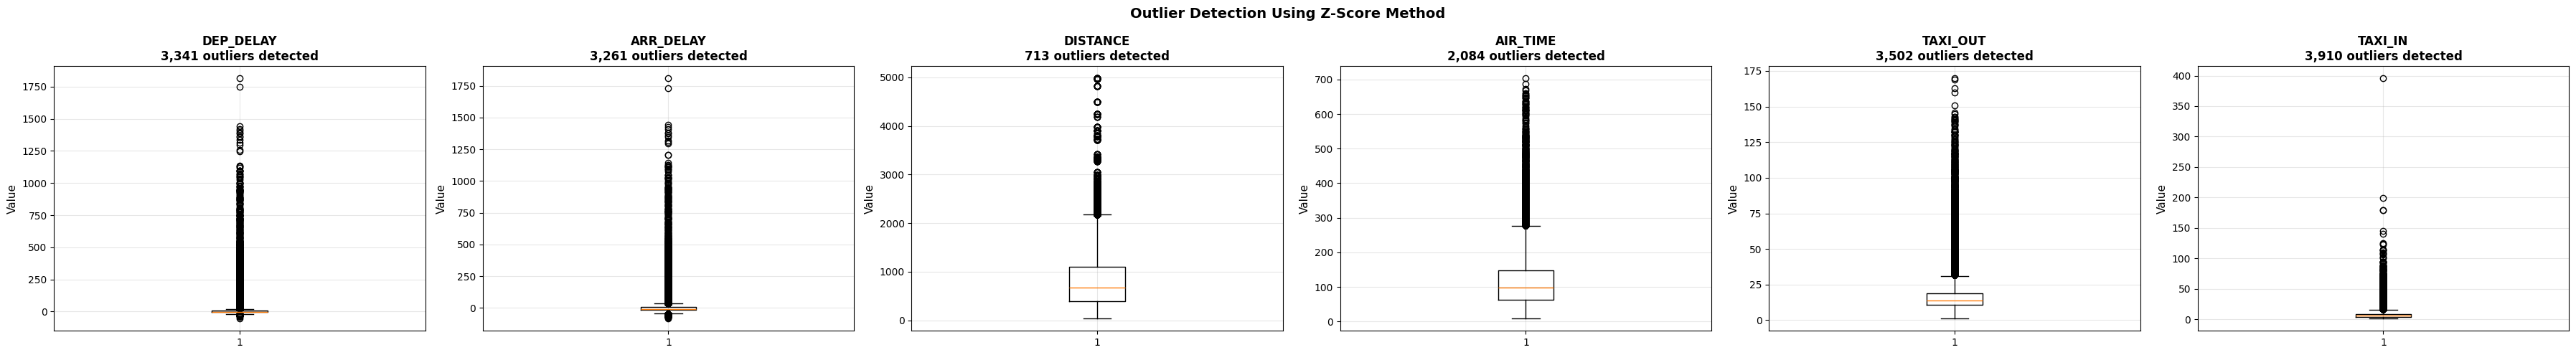

In [5]:
print("OUTLIER DETECTION")

columns_to_check = [
    'DEP_DELAY',
    'ARR_DELAY',
    'DISTANCE',
    'AIR_TIME',
    'TAXI_OUT',
    'TAXI_IN'
]

columns_to_check = [col for col in columns_to_check if col in df.columns]

if len(columns_to_check) == 0:
    print("⚠ No columns found for outlier detection.")
    print("Please check if column names are correct!")
    print("\nActual numeric columns available in dataset:")
    print(df.select_dtypes(include=[np.number]).columns.tolist())
else:
    print("Columns being checked for outliers:")
    for col in columns_to_check:
        print(f"  • {col}")
    print("\n")

    # Store which columns have outliers
    columns_with_outliers = []
    outlier_info = {}

    for col in columns_to_check:
        # Remove missing values
        clean_data = df[col].dropna()

        # Calculate Z-scores manually
        mean = clean_data.mean()
        std = clean_data.std()
        z_scores = np.abs((clean_data - mean) / std)

        # Find outliers (Z-score > 3)
        outliers = z_scores > 3
        outlier_count = outliers.sum()
        outlier_percent = (outlier_count / len(clean_data)) * 100

        # If outliers exist, add to list
        if outlier_count > 0:
            columns_with_outliers.append(col)
            outlier_info[col] = {
                'count': outlier_count,
                'percent': outlier_percent
            }

print("OUTLIER DETECTION RESULTS")
print("\n")
if len(columns_with_outliers) > 0:
        print(f"Outliers detected in {len(columns_with_outliers)} column(s):\n")
        for col in columns_with_outliers:
            info = outlier_info[col]
            print(f"  • {col}: {info['count']:,} outliers ({info['percent']:.2f}%)")
        print("\n")

        num_cols = len(columns_with_outliers)
        fig, axes = plt.subplots(1, num_cols, figsize=(6 * num_cols, 5))

        # Handle case where there's only one column
        if num_cols == 1:
            axes = [axes]

        for i, col in enumerate(columns_with_outliers):
            # Create boxplot
            axes[i].boxplot(df[col].dropna(), vert=True)
            axes[i].set_title(f'{col}\n{outlier_info[col]["count"]:,} outliers detected',
                             fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Value', fontsize=11)
            axes[i].grid(True, alpha=0.3)

        plt.suptitle('Outlier Detection Using Z-Score Method', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

else:
        print("✓ No outliers detected in any column!")
        print("(Using Z-score method with threshold > 3)")




### OUTLIER HANDLING:
For handling outliers, the IQR technique is used by defining the whiskers based on the boundaries and computing the lower limit and upper limit accordingly.

Fixed DEP_DELAY:
  • Lower Limit: -21.50
  • Upper Limit: 22.50

Fixed ARR_DELAY:
  • Lower Limit: -45.50
  • Upper Limit: 38.50

Fixed DISTANCE:
  • Lower Limit: -680.00
  • Upper Limit: 2176.00

Fixed AIR_TIME:
  • Lower Limit: -67.00
  • Upper Limit: 277.00

Fixed TAXI_OUT:
  • Lower Limit: -1.00
  • Upper Limit: 31.00

Fixed TAXI_IN:
  • Lower Limit: -3.50
  • Upper Limit: 16.50



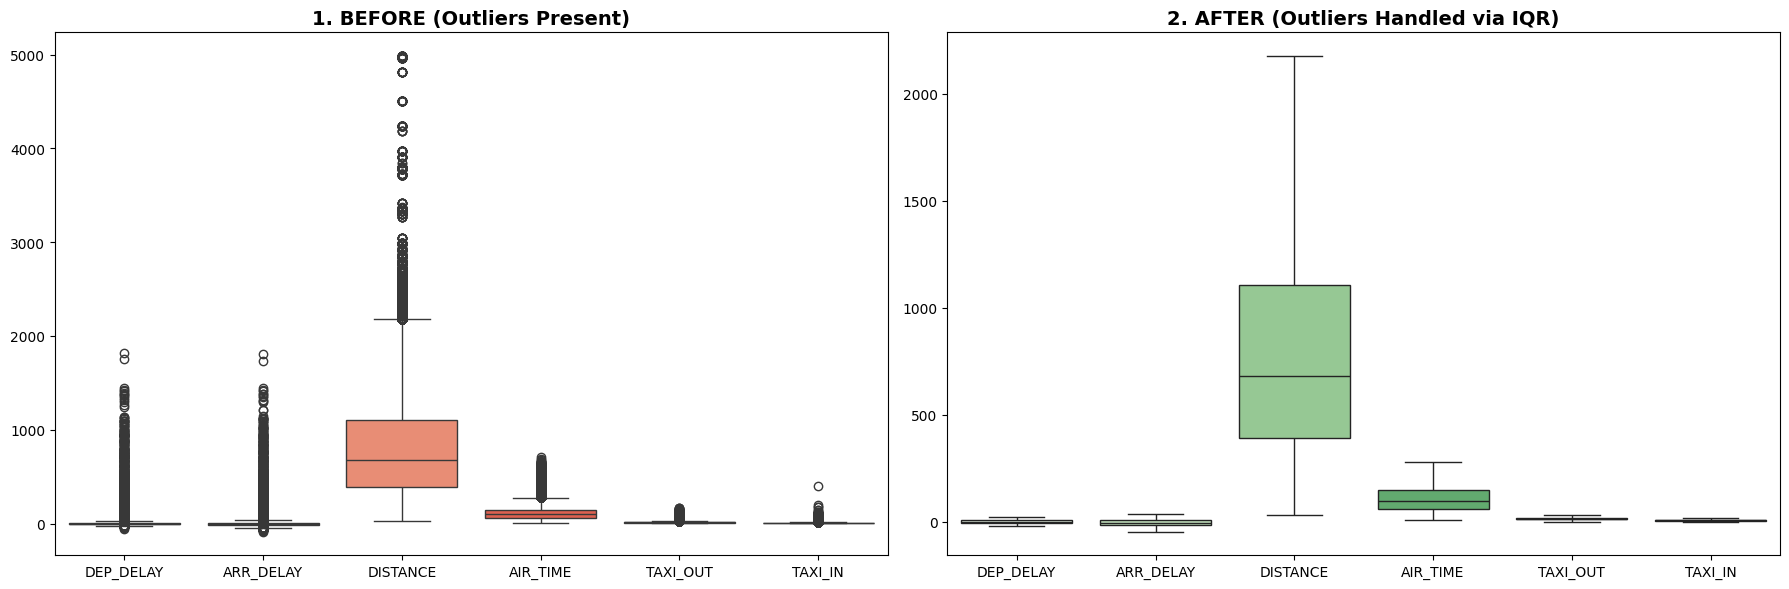

✓ DONE! Final file 'final_cleaned_dataset.csv' saved with all missing values and outliers handled.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
columns_to_fix = ['DEP_DELAY', 'ARR_DELAY', 'DISTANCE', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN']
columns_to_fix = [col for col in columns_to_fix if col in df.columns]

df_before_outliers = df.copy()

for col in columns_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define the 'Whisker' boundaries (Standard for Boxplots)
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap the values in the ORIGINAL df
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

    print(f"Fixed {col}:")
    print(f"  • Lower Limit: {lower_limit:.2f}")
    print(f"  • Upper Limit: {upper_limit:.2f}\n")

# VISUALIZATION: Before vs. After
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Before (Has outliers)
sns.boxplot(data=df_before_outliers[columns_to_fix], ax=axes[0], palette="Reds")
axes[0].set_title("1. BEFORE (Outliers Present)", fontsize=14, fontweight='bold')

# Plot After (Outliers handled)
sns.boxplot(data=df[columns_to_fix], ax=axes[1], palette="Greens")
axes[1].set_title("2. AFTER (Outliers Handled via IQR)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

file_name = "final_cleaned_dataset.csv"
df.to_csv(file_name, index=False)

print(f"✓ DONE! Final file '{file_name}' saved with all missing values and outliers handled.")

files.download(file_name)

# WEEK 4 - DEEP DIVE IN EDA


Shape of Dataset: (200000, 28)

Columns:
 Index(['FL_DATE', 'OP_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'Unnamed: 27'],
      dtype='object')

Missing Values:
 FL_DATE                     0
OP_CARRIER                  0
OP_CARRIER_FL_NUM           0
ORIGIN                      0
DEST                        0
CRS_DEP_TIME                0
DEP_TIME                    0
DEP_DELAY                   0
TAXI_OUT                    0
WHEELS_OFF                  0
WHEELS_ON                   0
TAXI_IN                     0
CRS_ARR_TIME                0
ARR_TIME                    0
ARR_DELAY                   0
CANCE

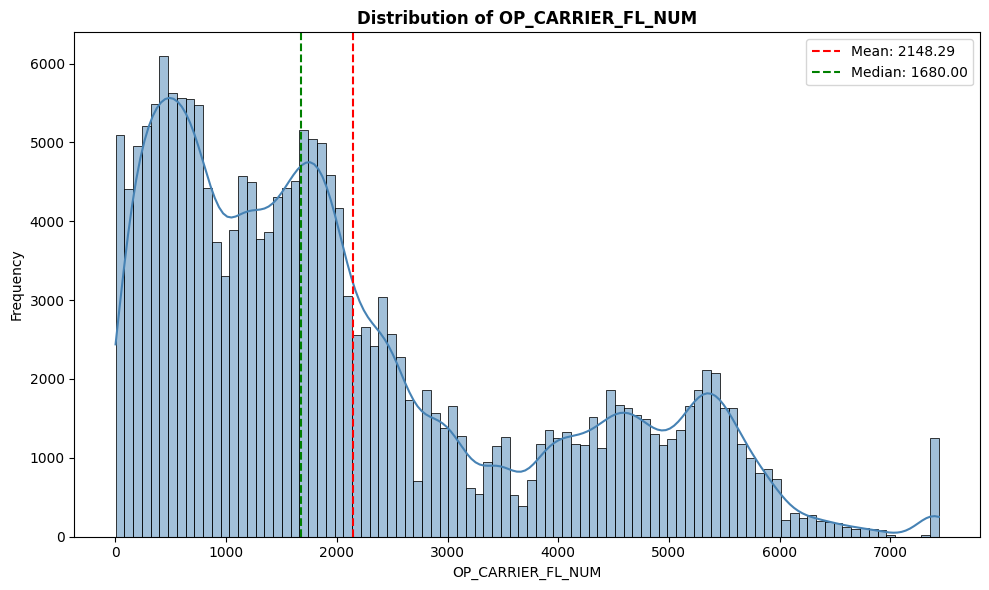

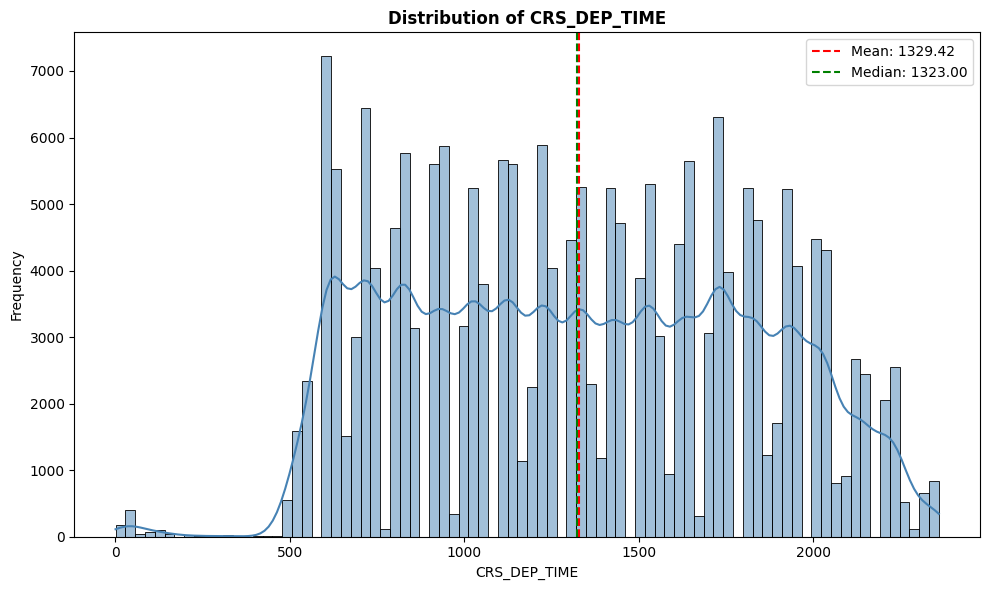

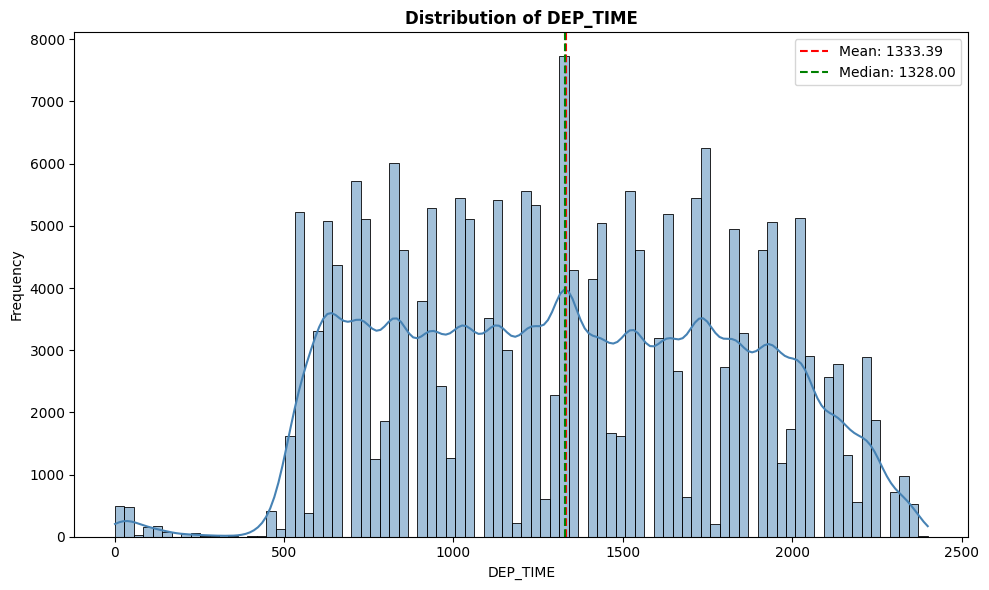

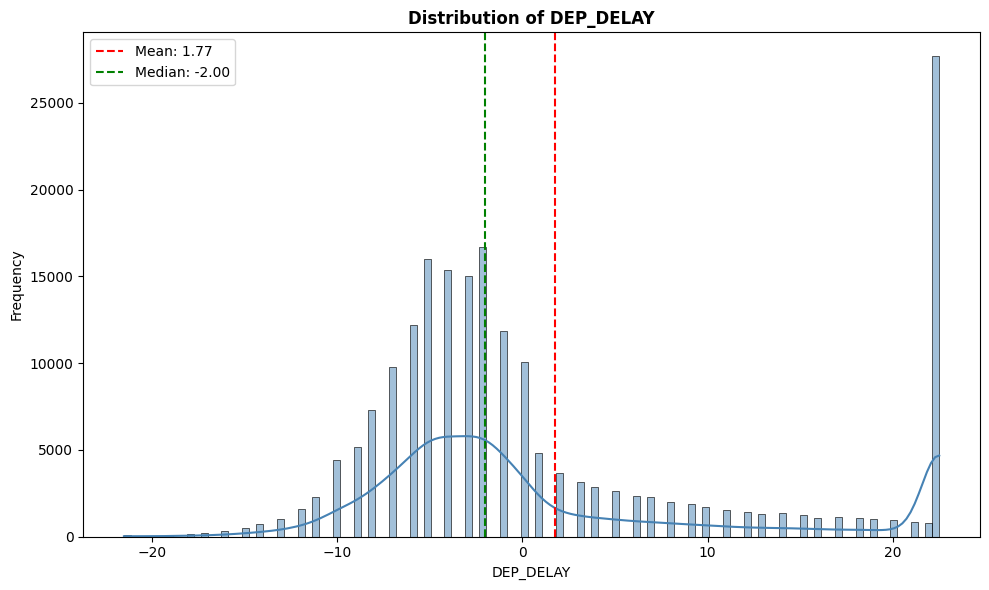

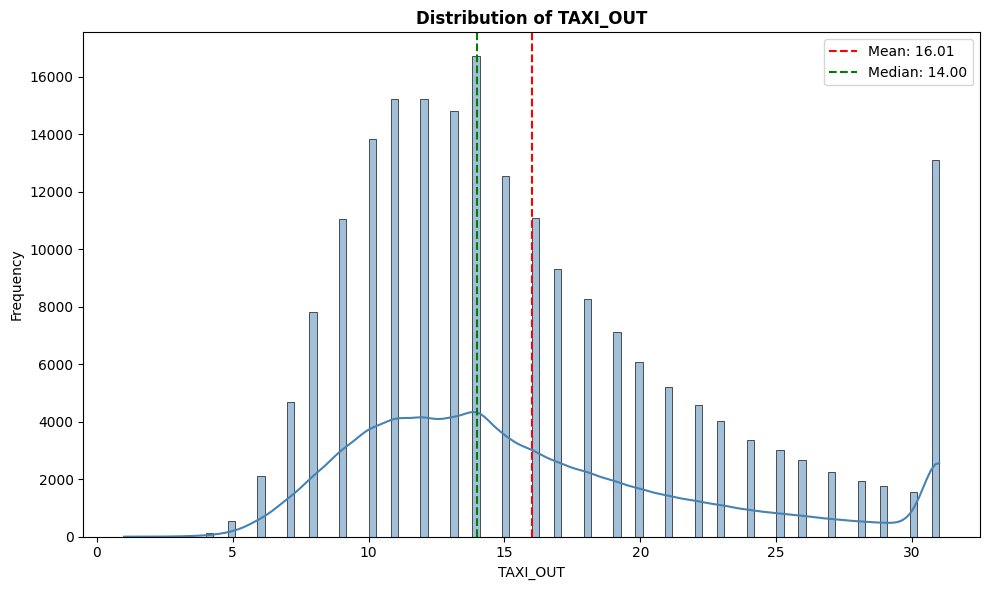

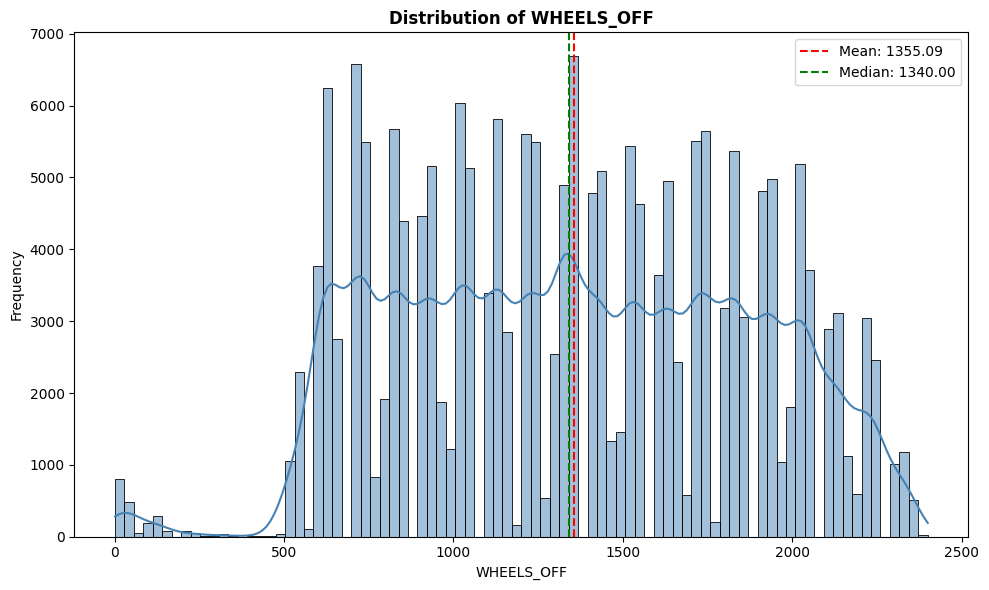

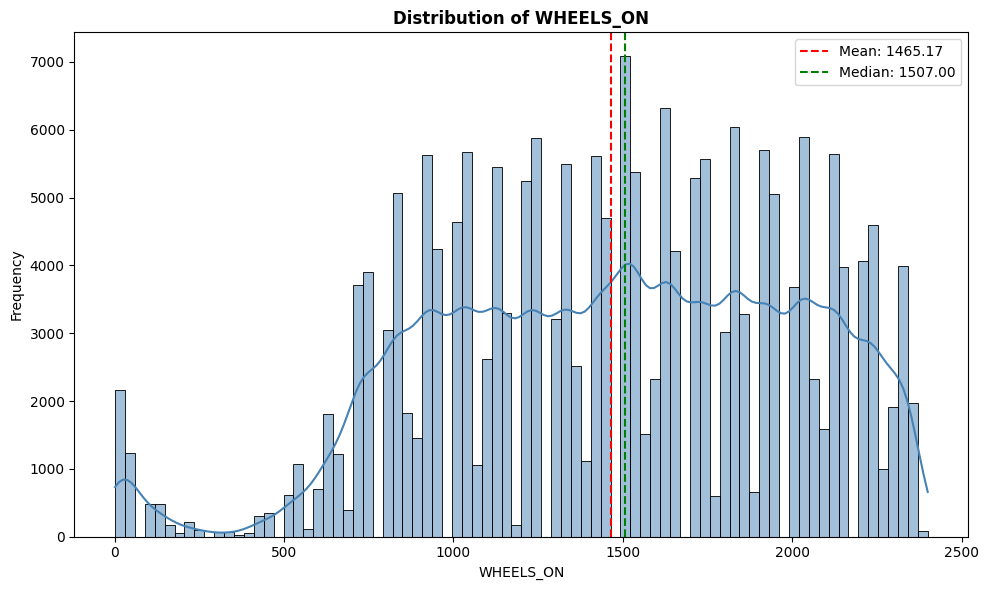

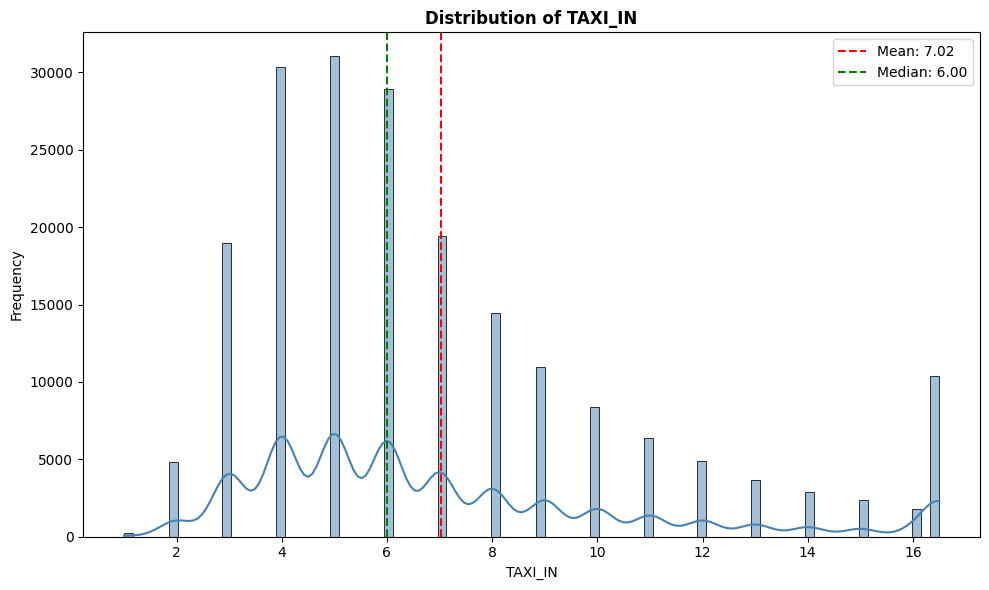

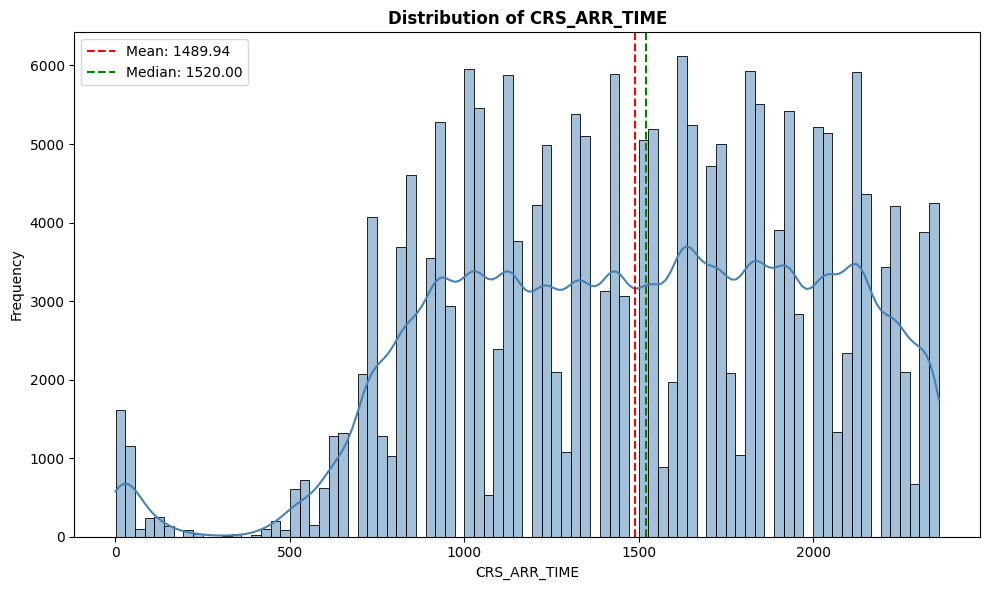

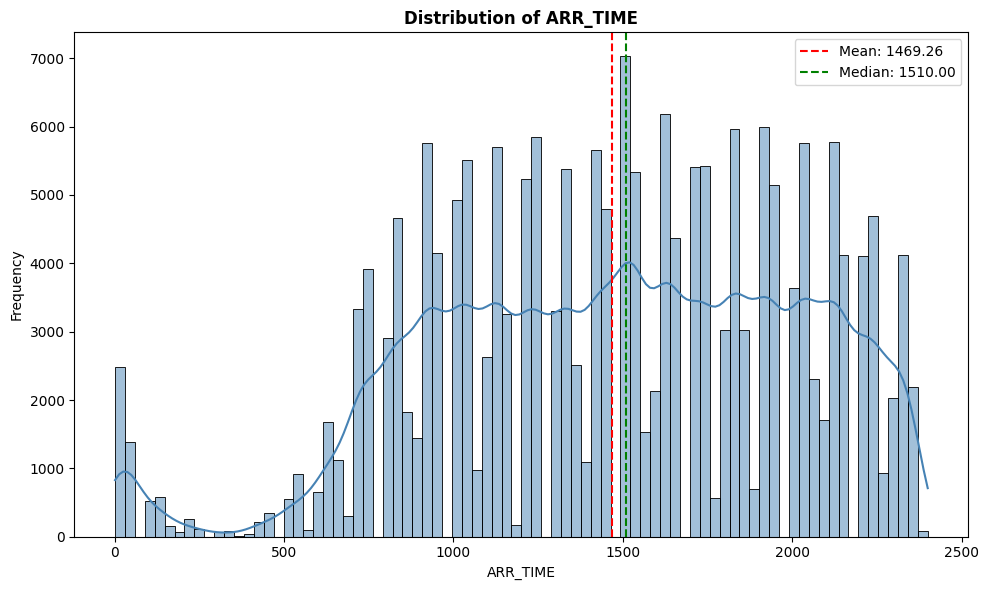

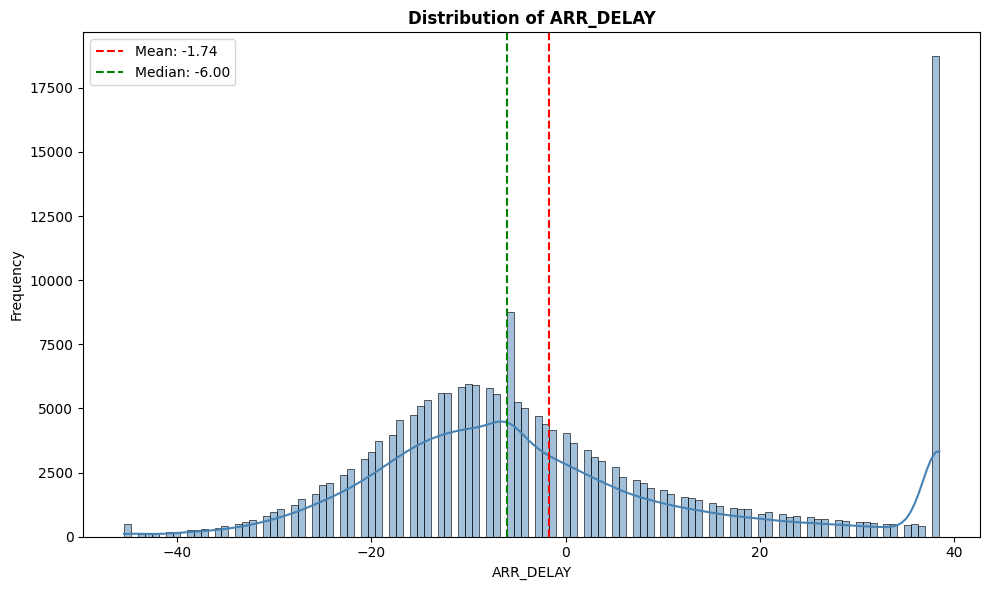

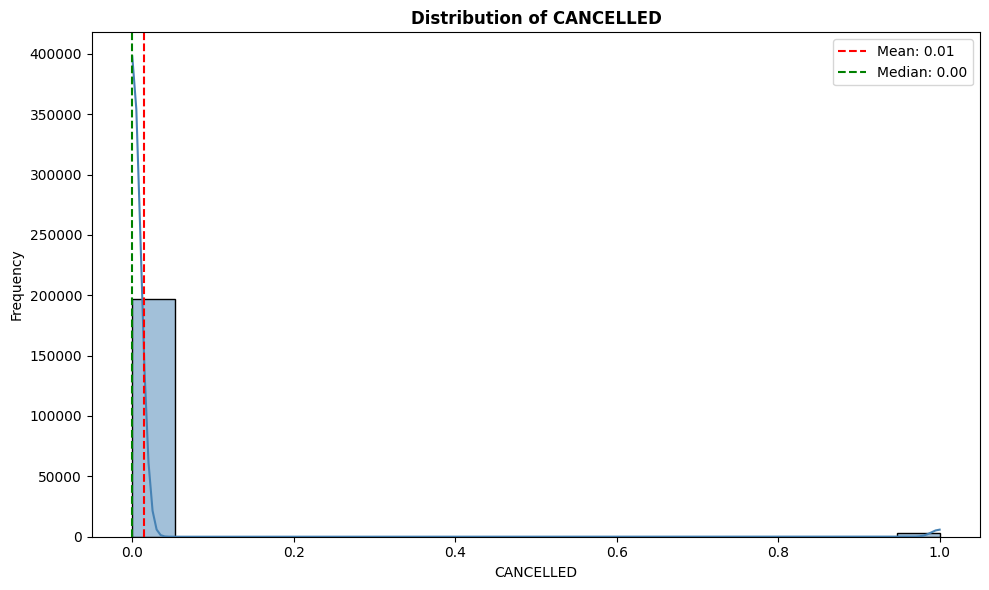

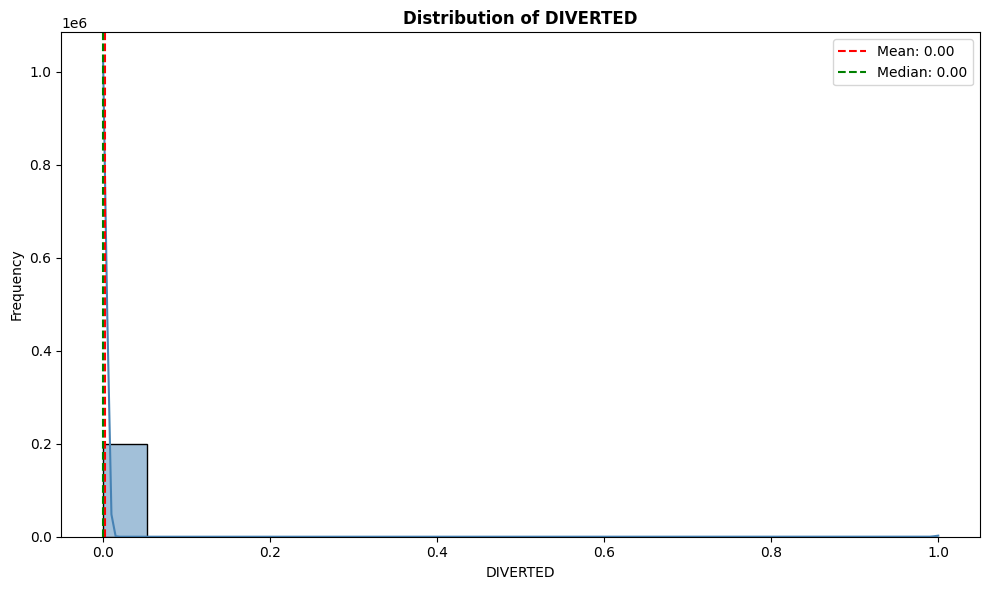

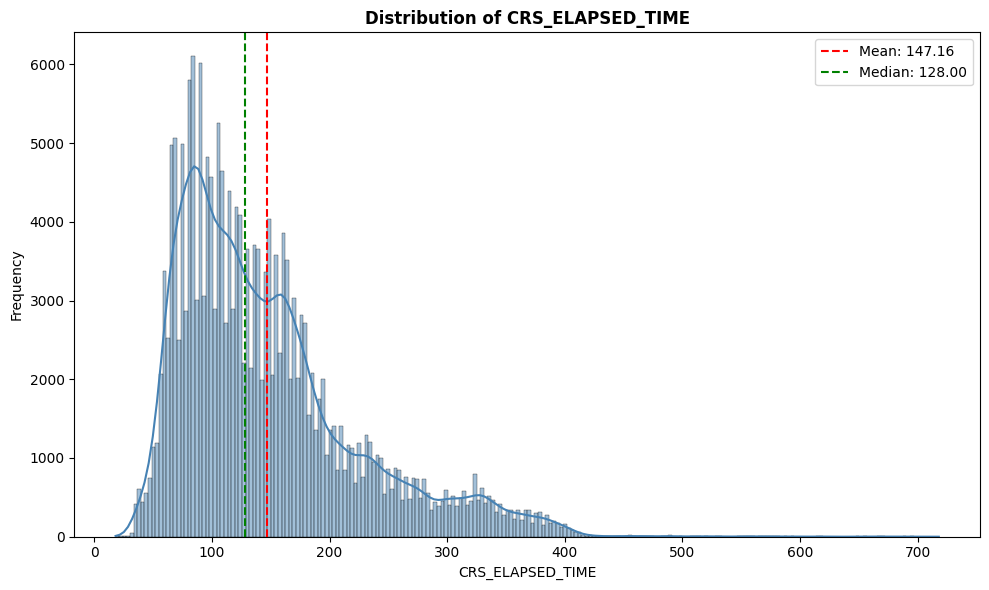

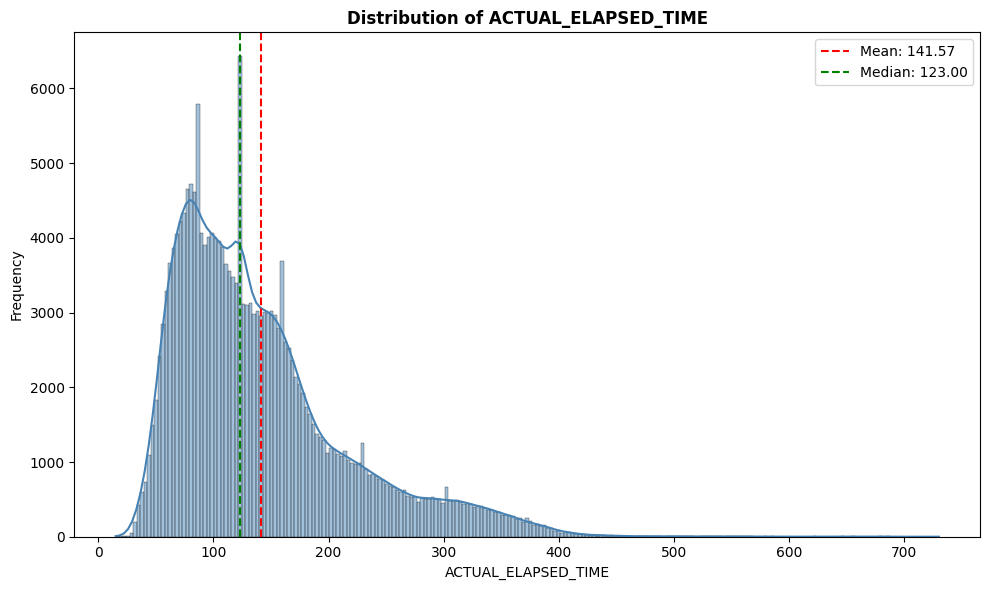

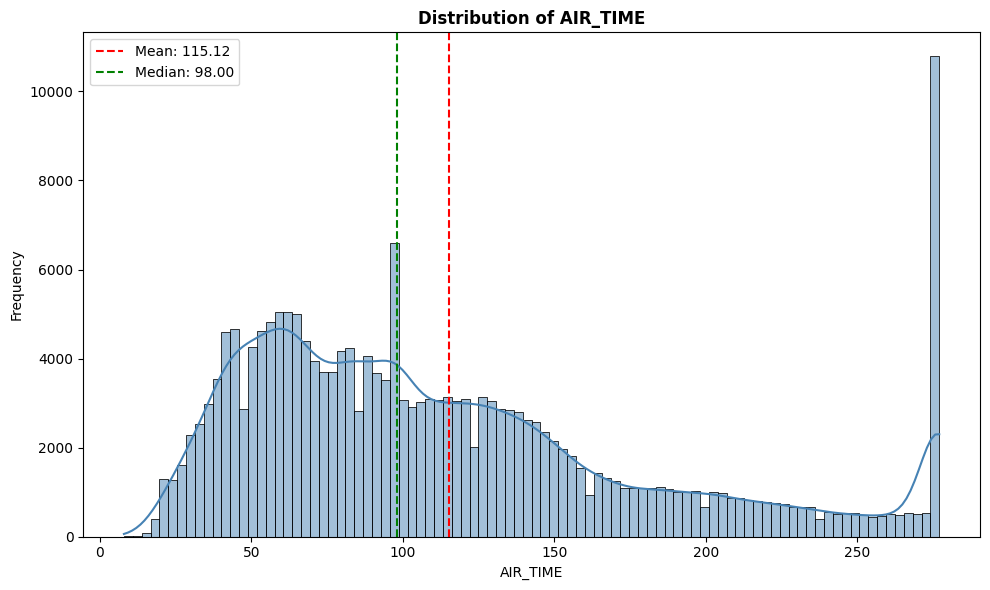

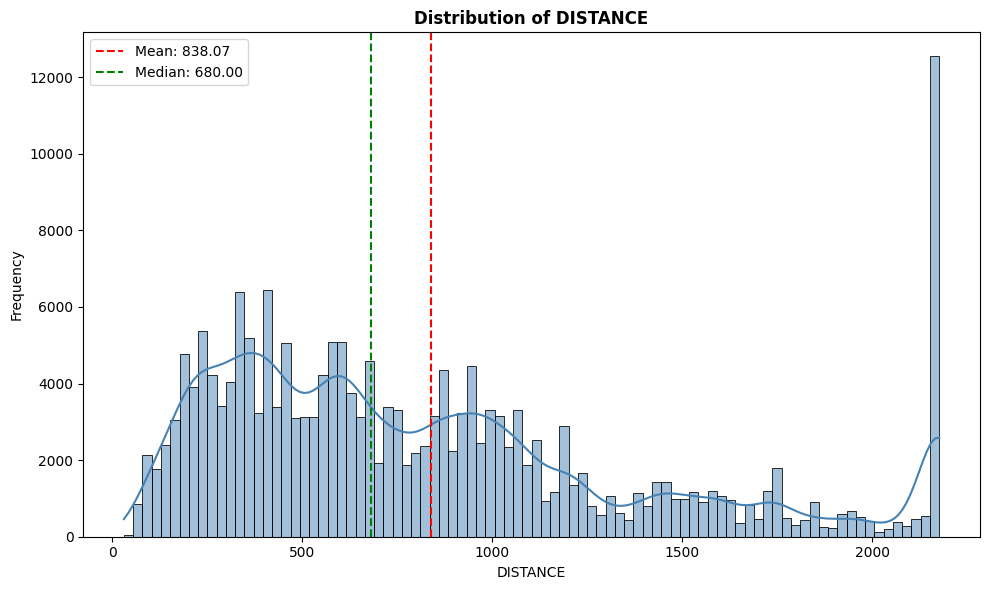

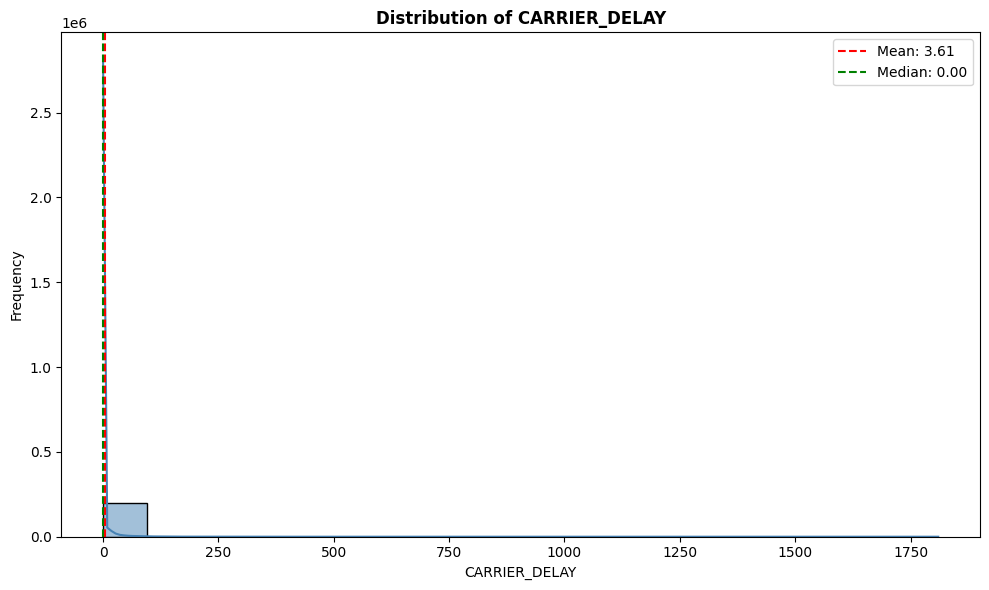

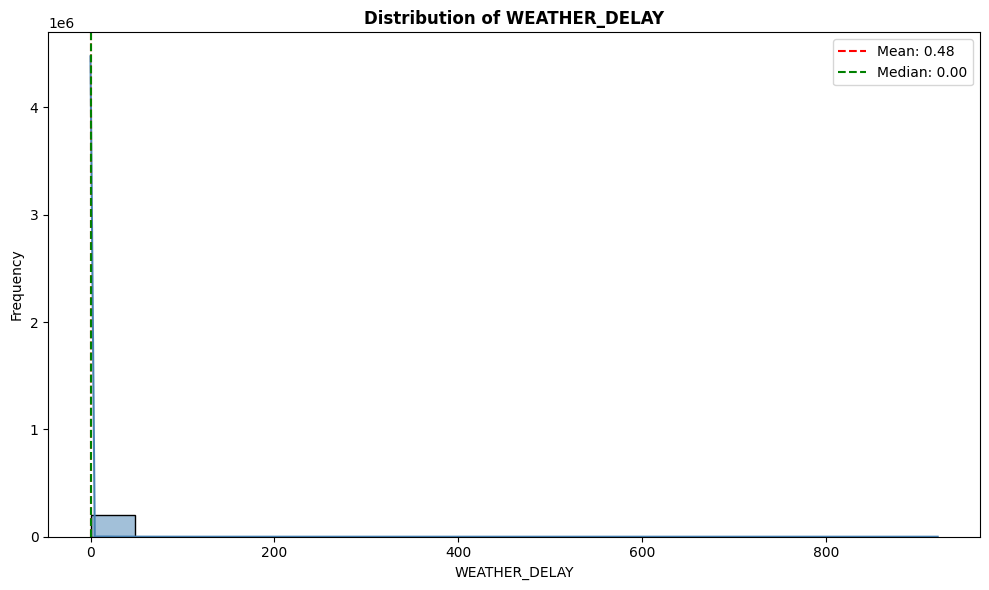

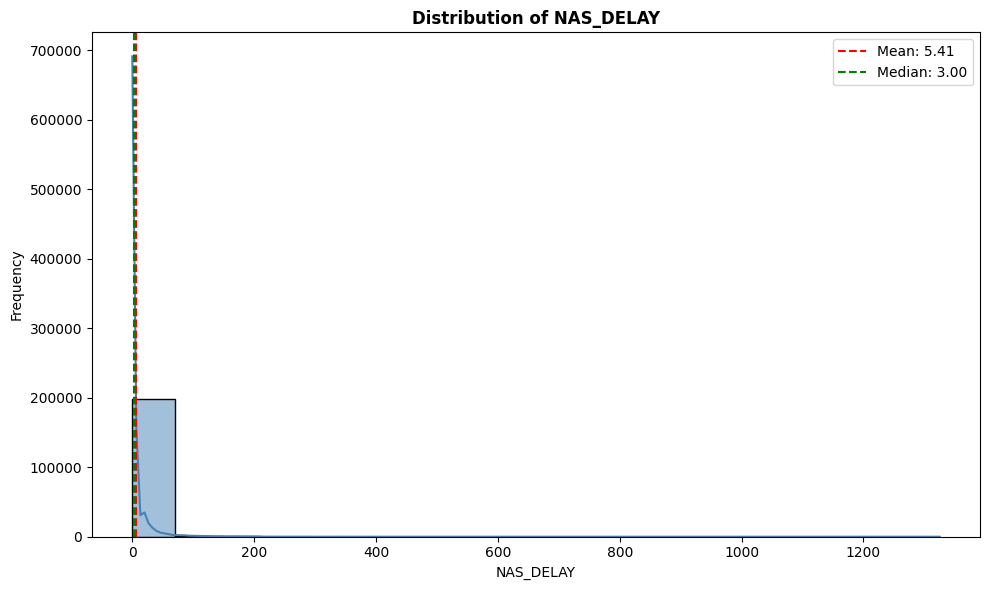

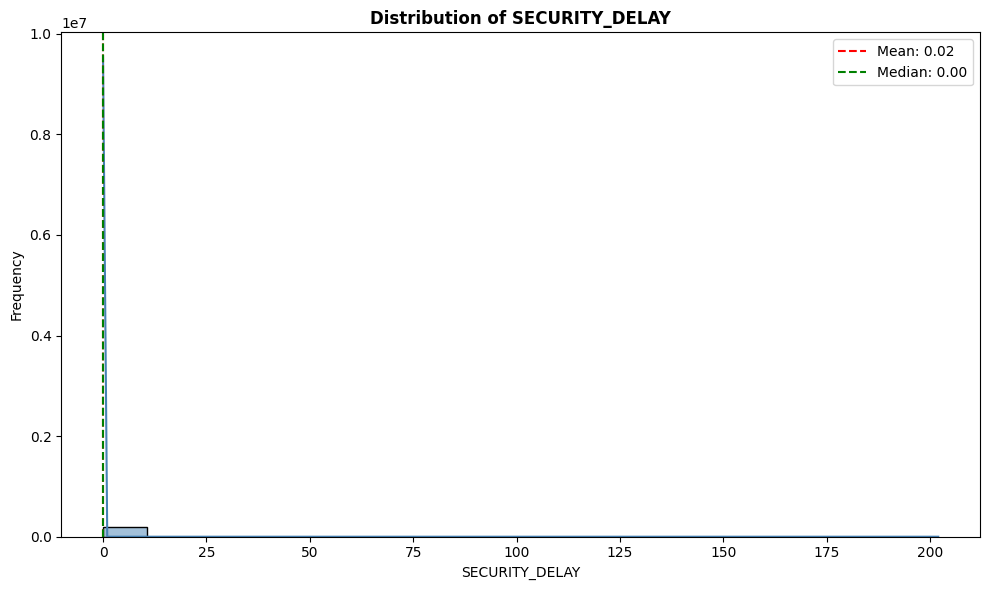

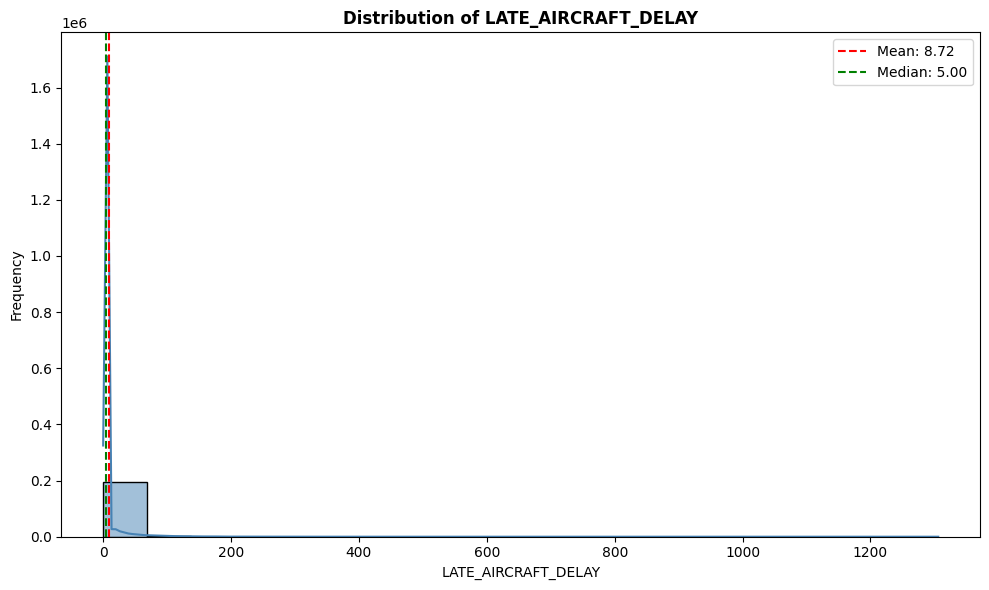

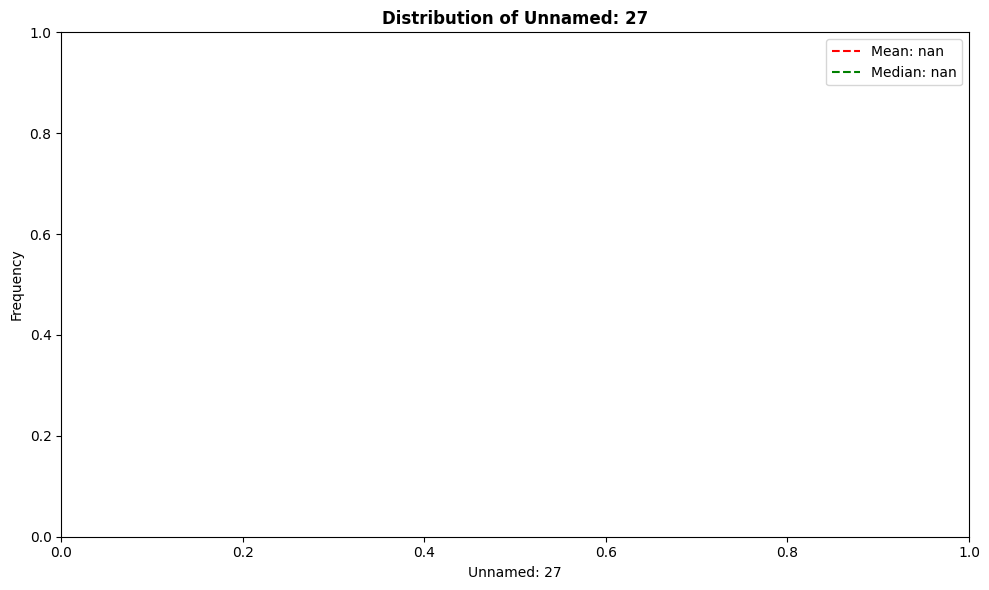

✓ Histograms created!

Creating Boxplots...


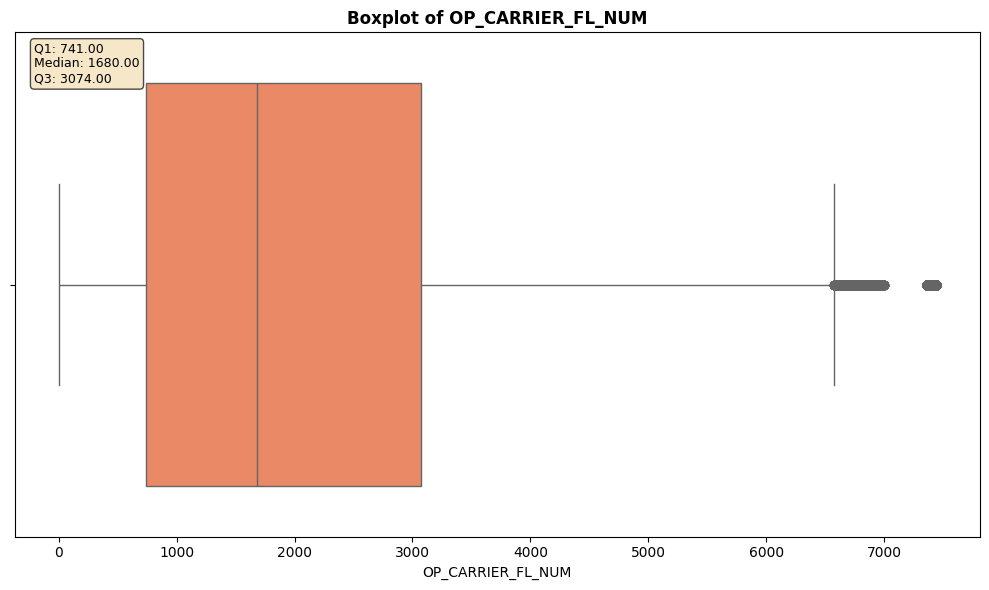

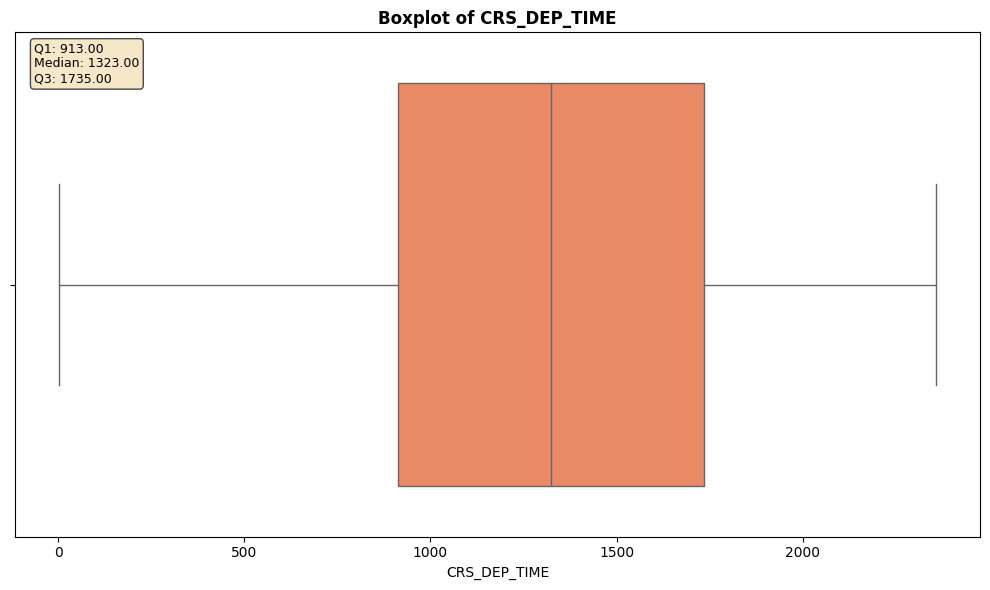

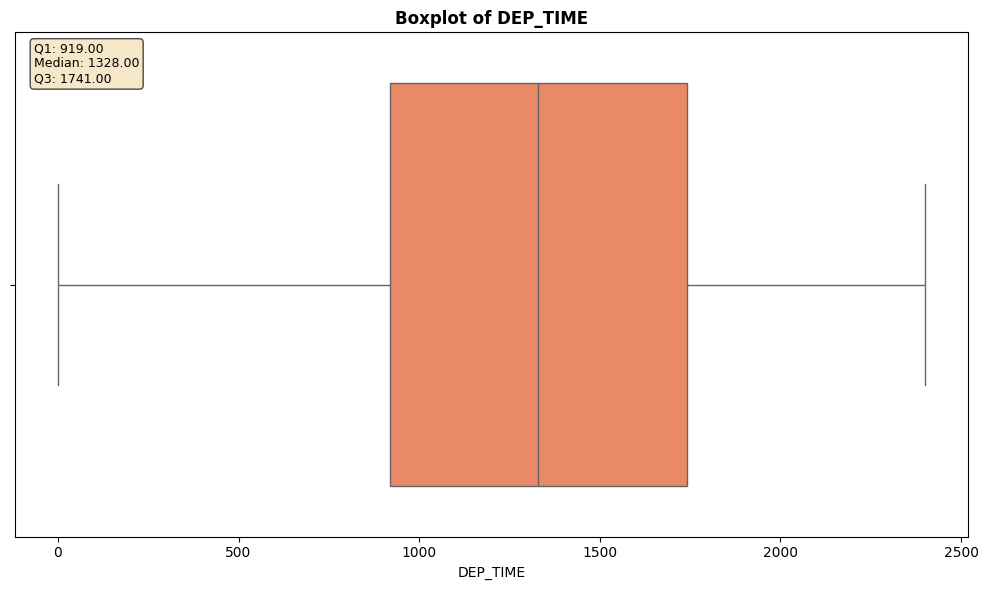

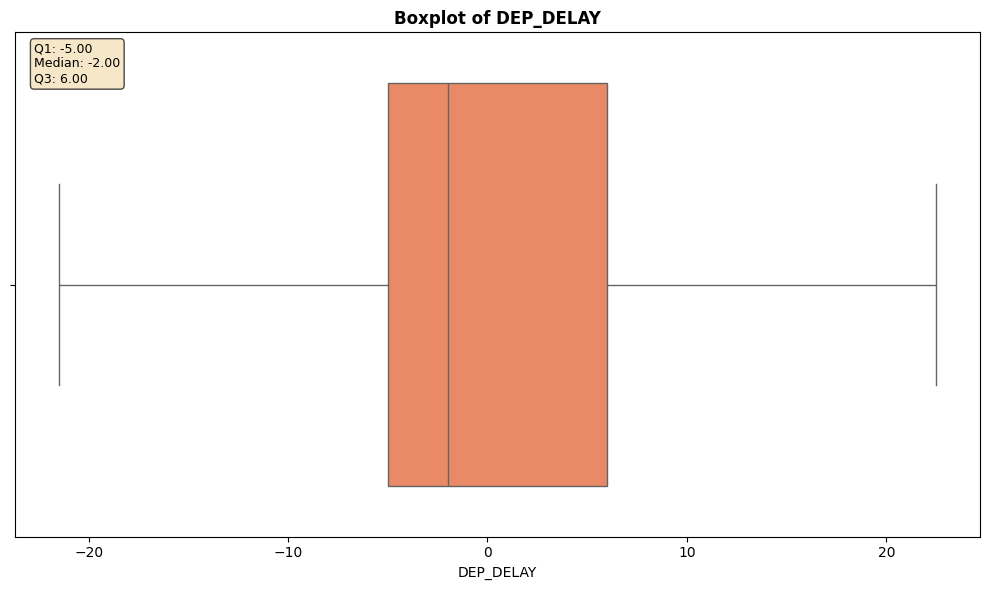

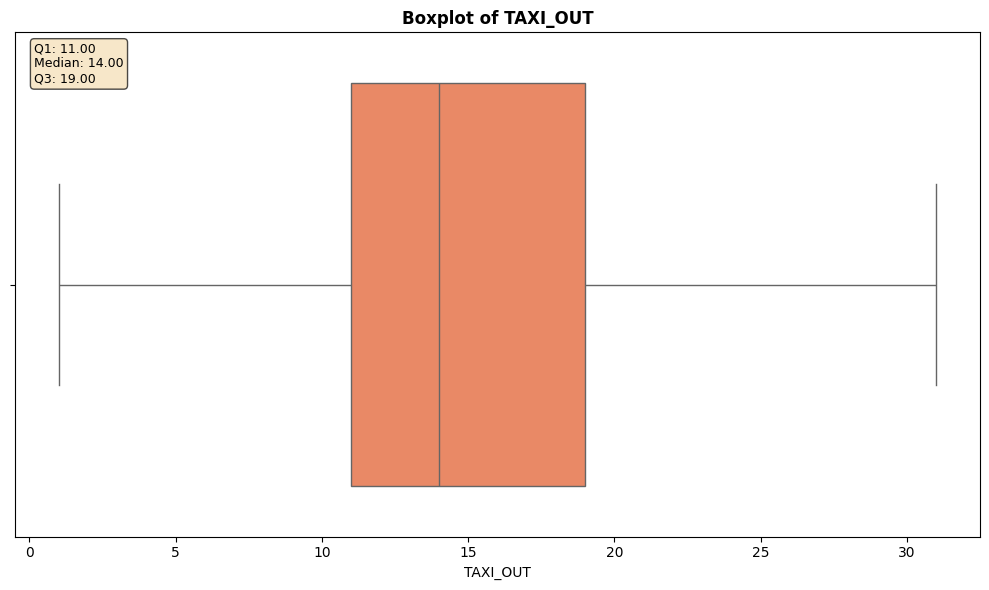

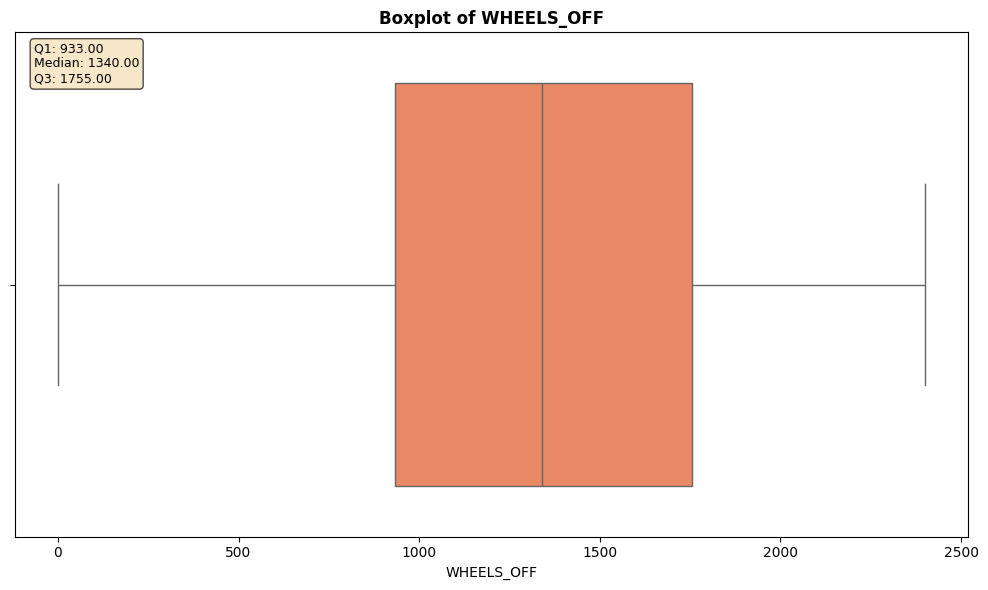

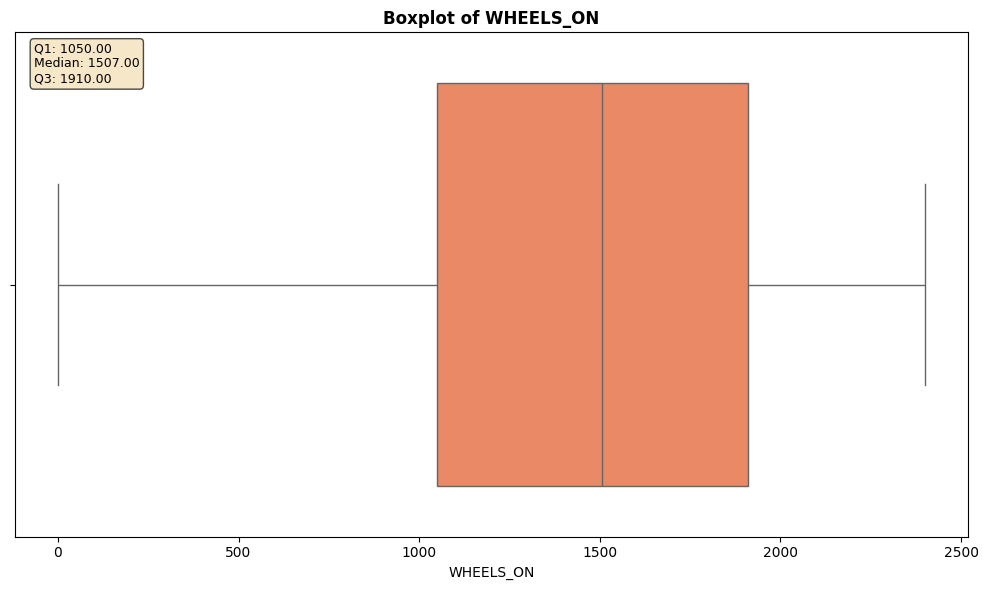

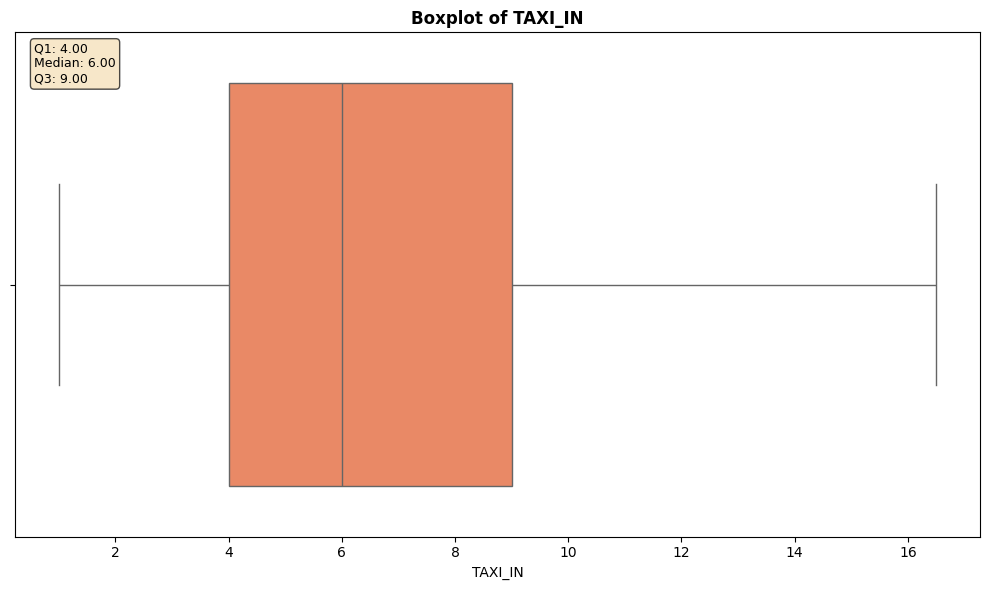

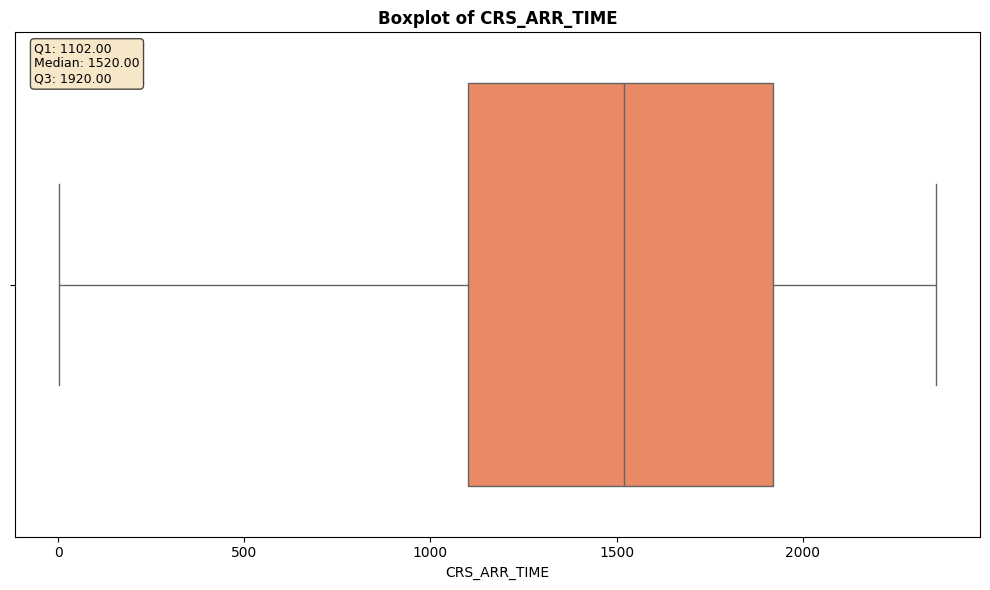

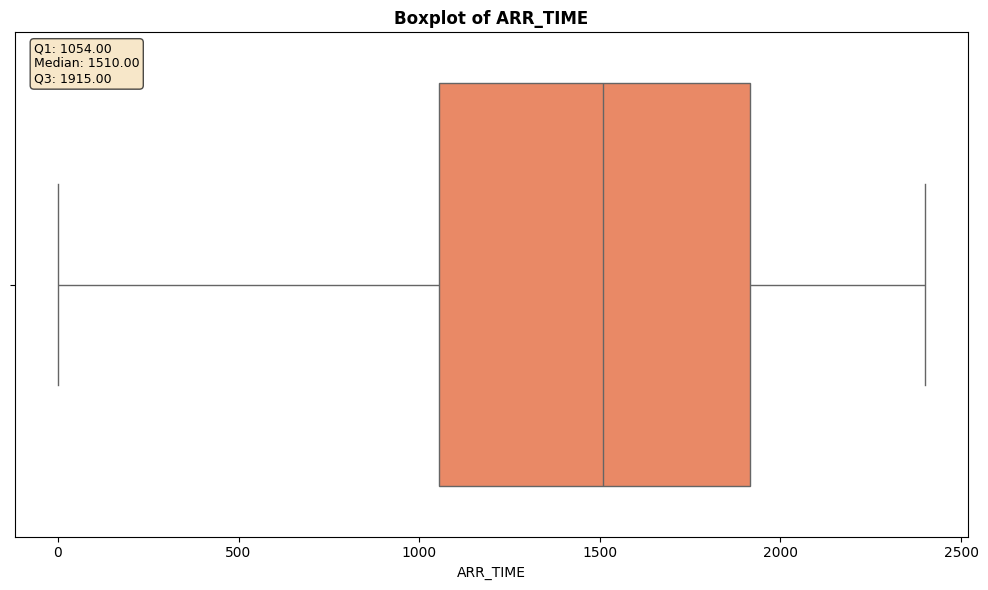

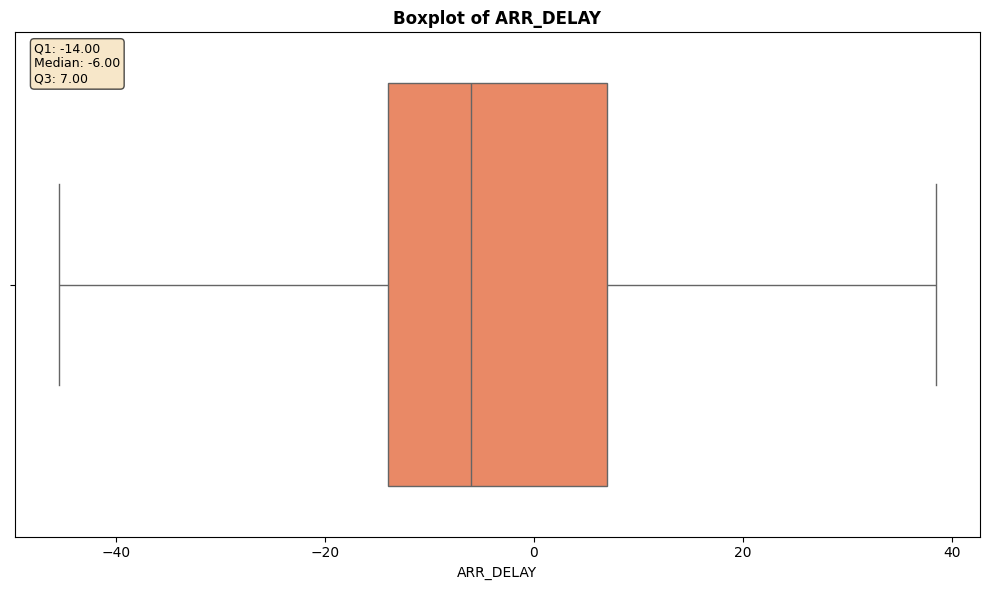

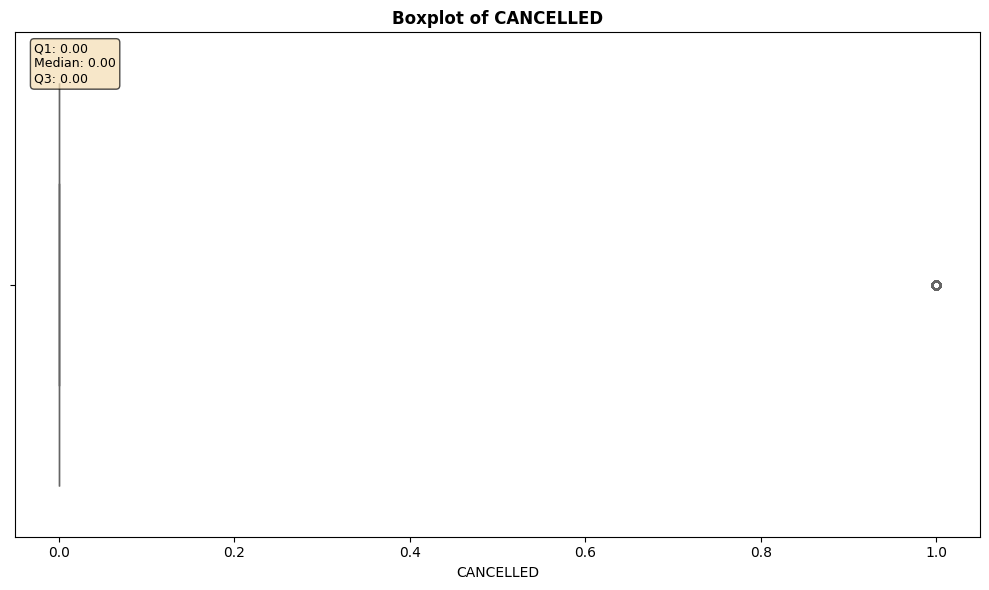

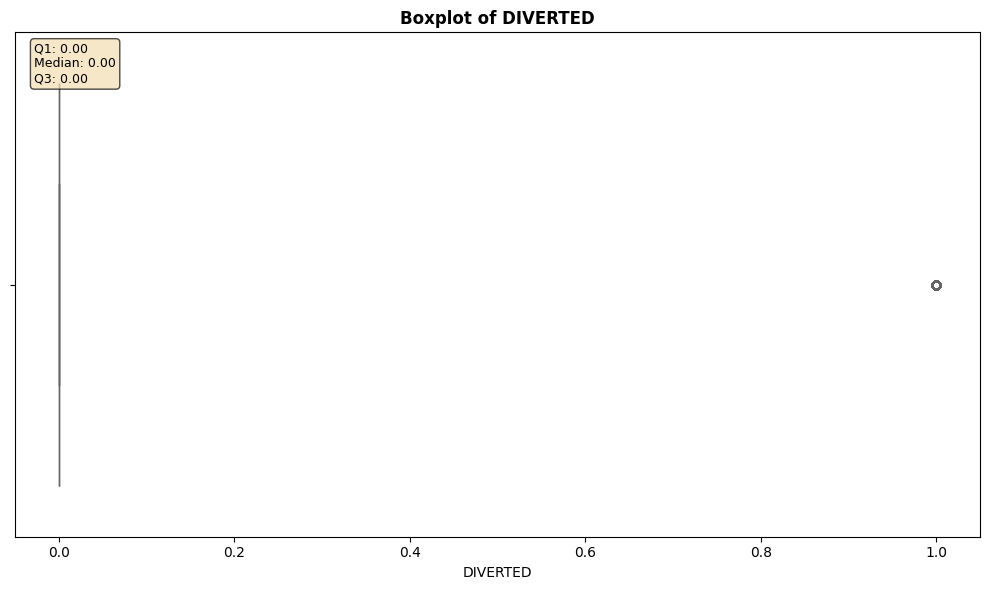

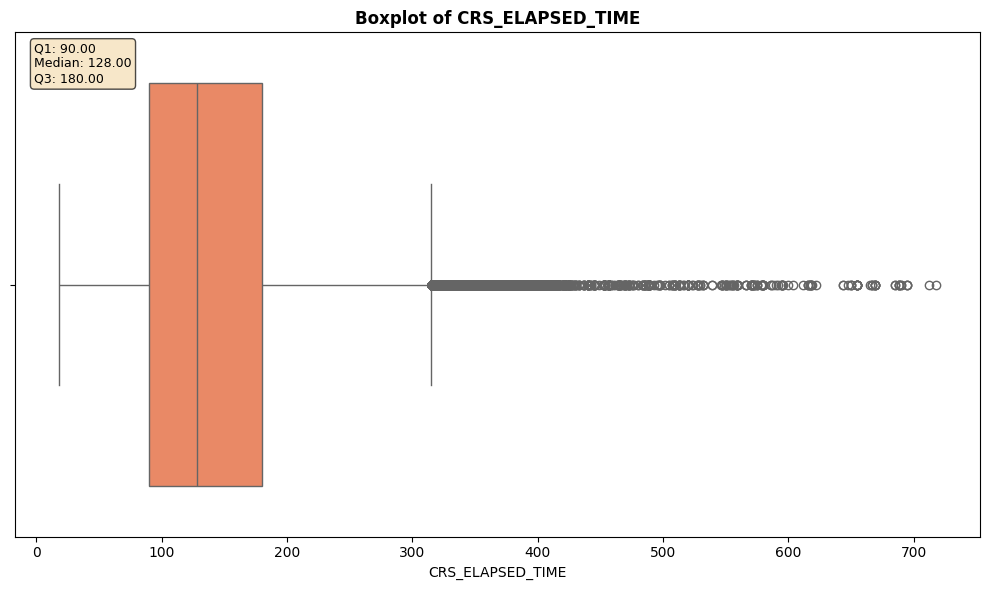

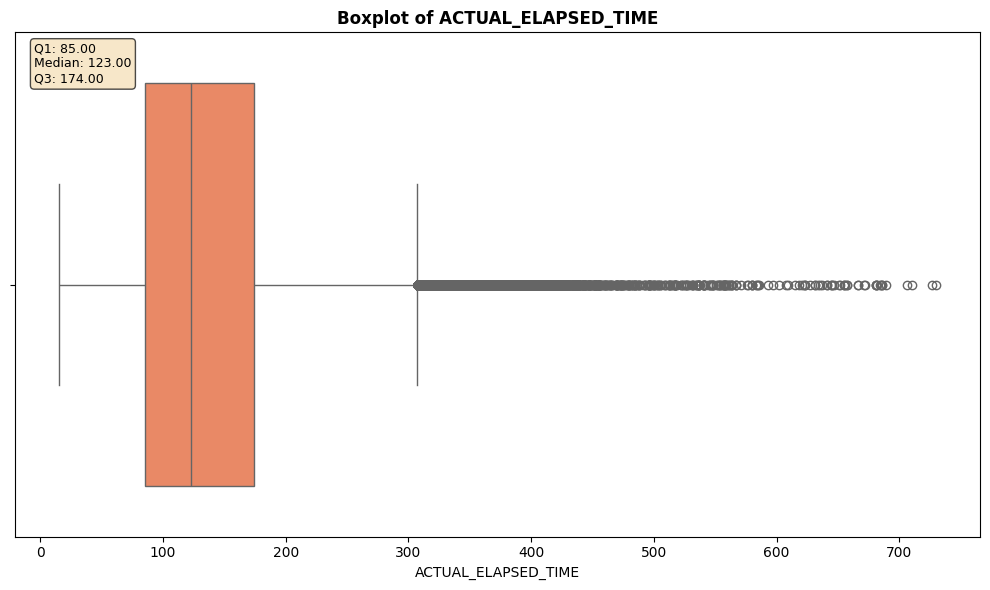

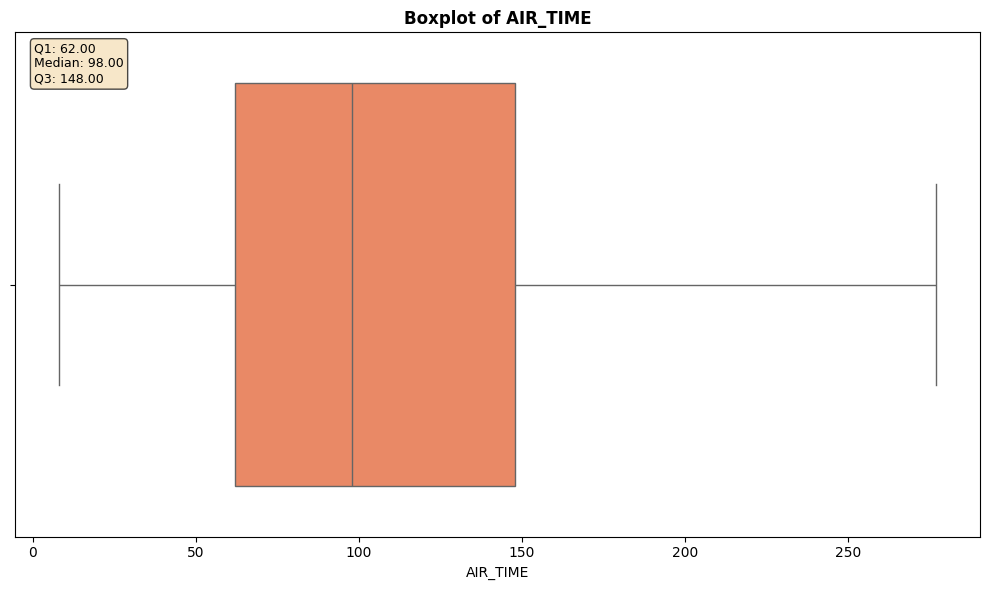

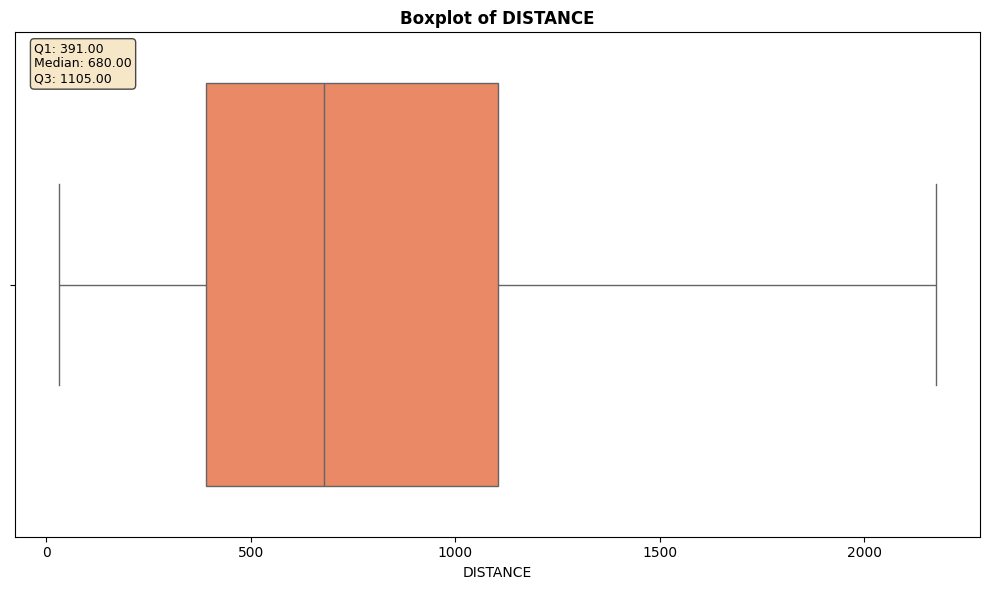

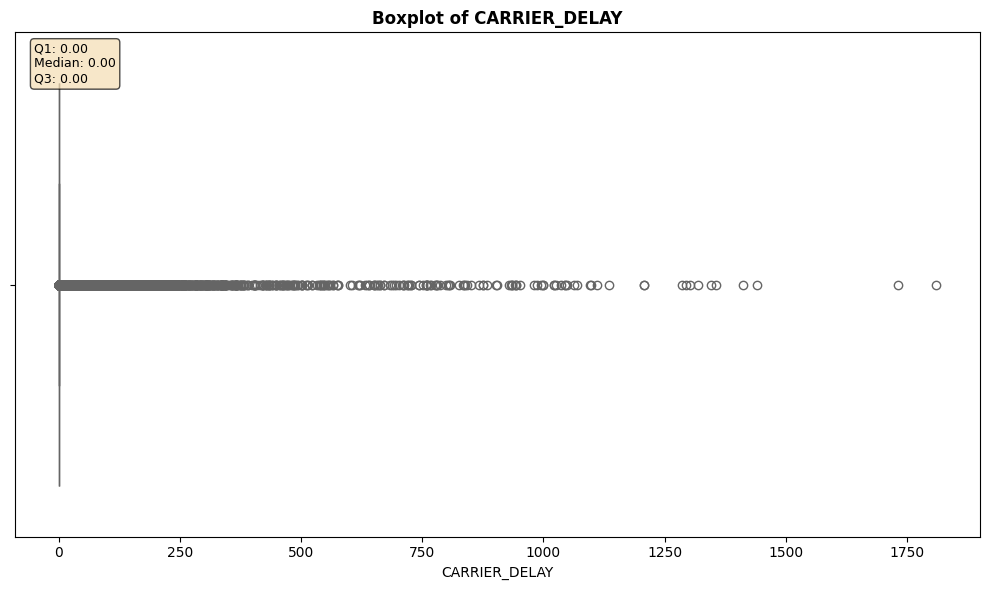

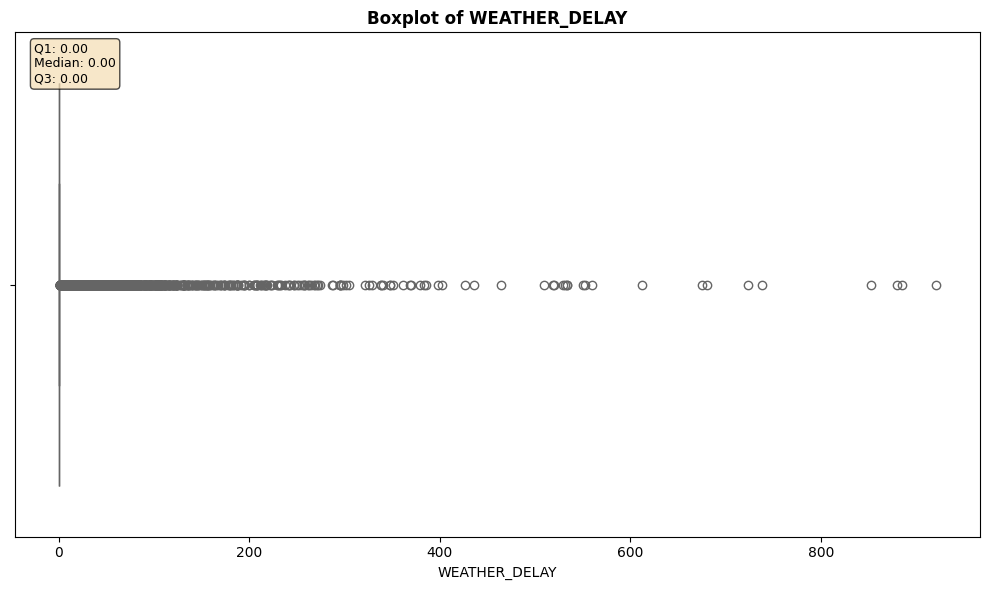

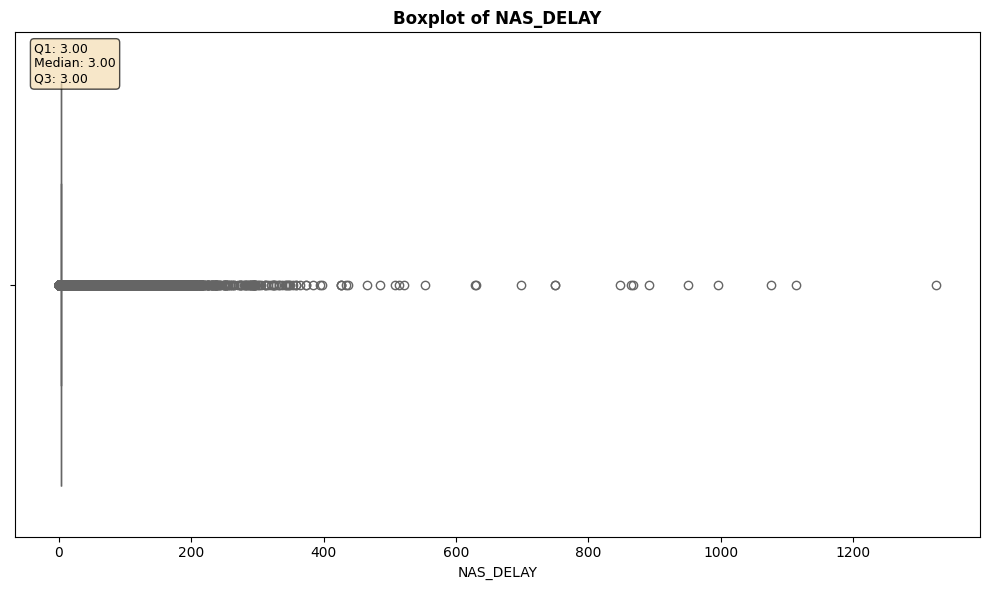

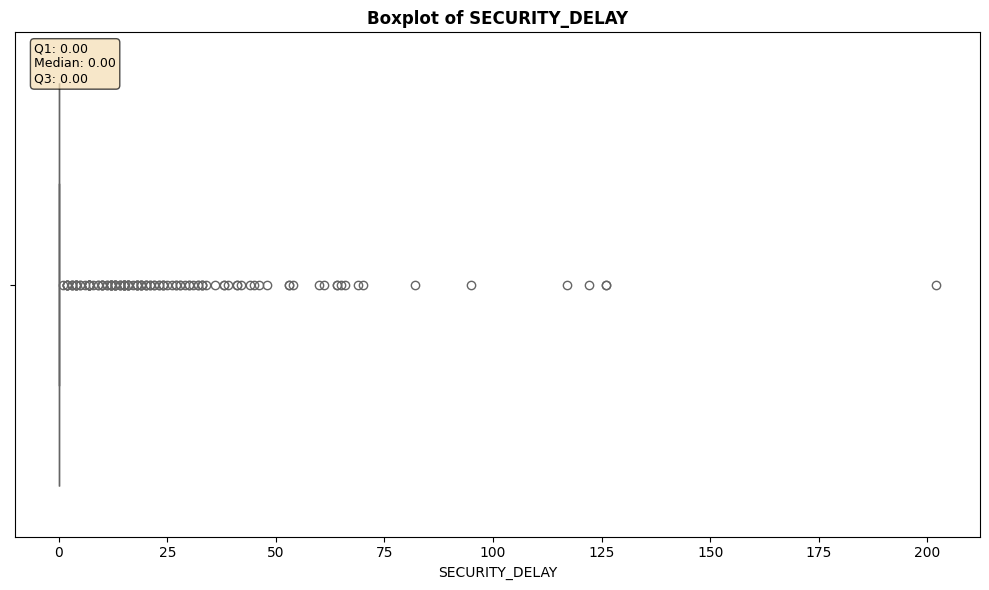

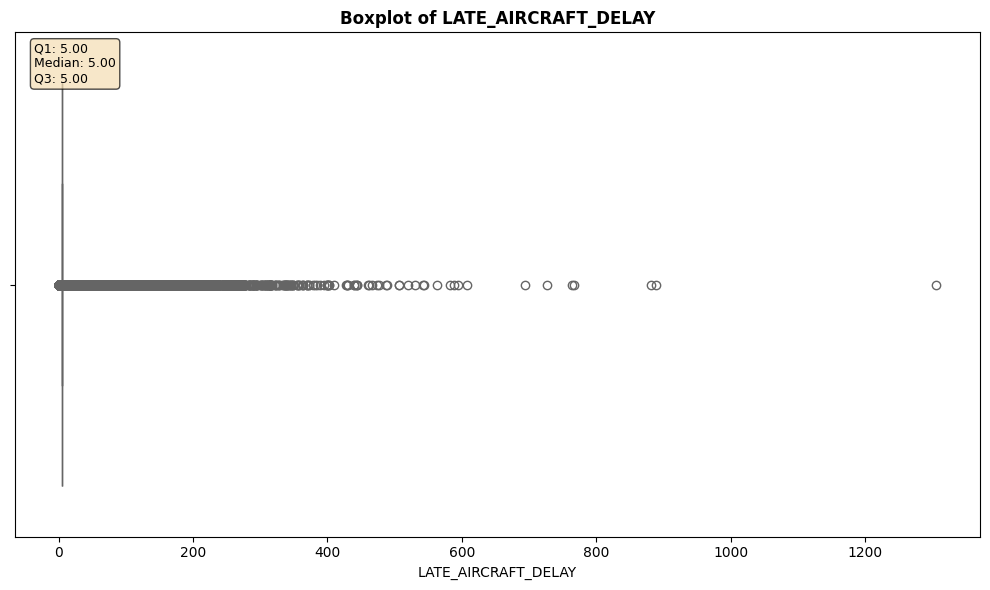

  ⚠ Skipping boxplot for Unnamed: 27: No valid data to plot after dropping NaNs.
✓ Boxplots created!

✅ Univariate Analysis Completed!
BIVARIATE ANALYSIS

Creating Correlation Heatmap...


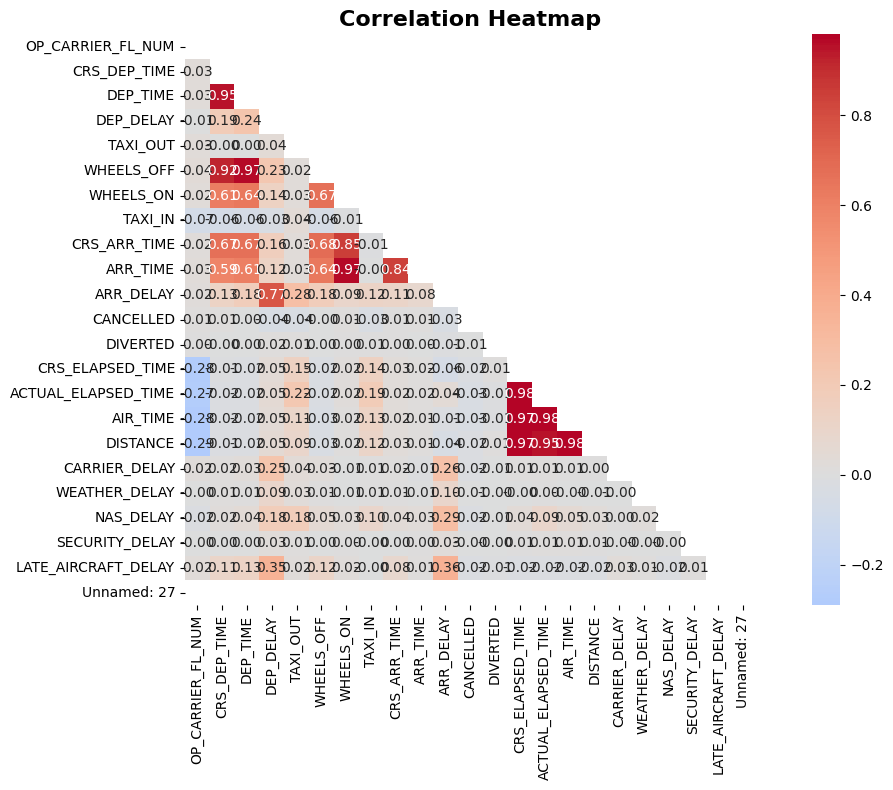

✓ Correlation heatmap created!

Top 5 Strongest Correlations:
------------------------------------------------------------
AIR_TIME ↔ DISTANCE: 0.980
CRS_ELAPSED_TIME ↔ ACTUAL_ELAPSED_TIME: 0.978
ACTUAL_ELAPSED_TIME ↔ AIR_TIME: 0.976
CRS_ELAPSED_TIME ↔ DISTANCE: 0.974
CRS_ELAPSED_TIME ↔ AIR_TIME: 0.971

Creating Scatter Plots...


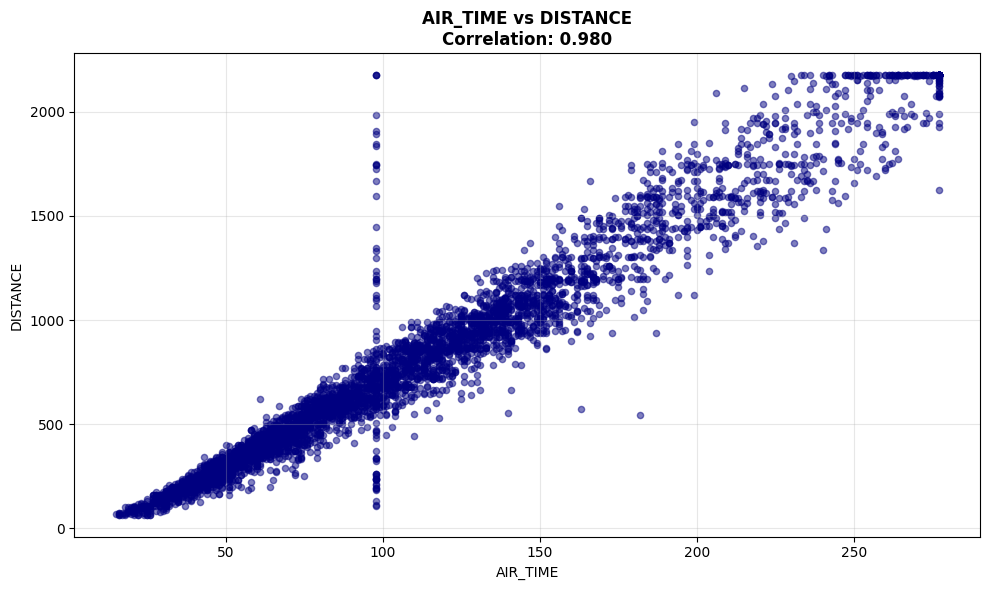

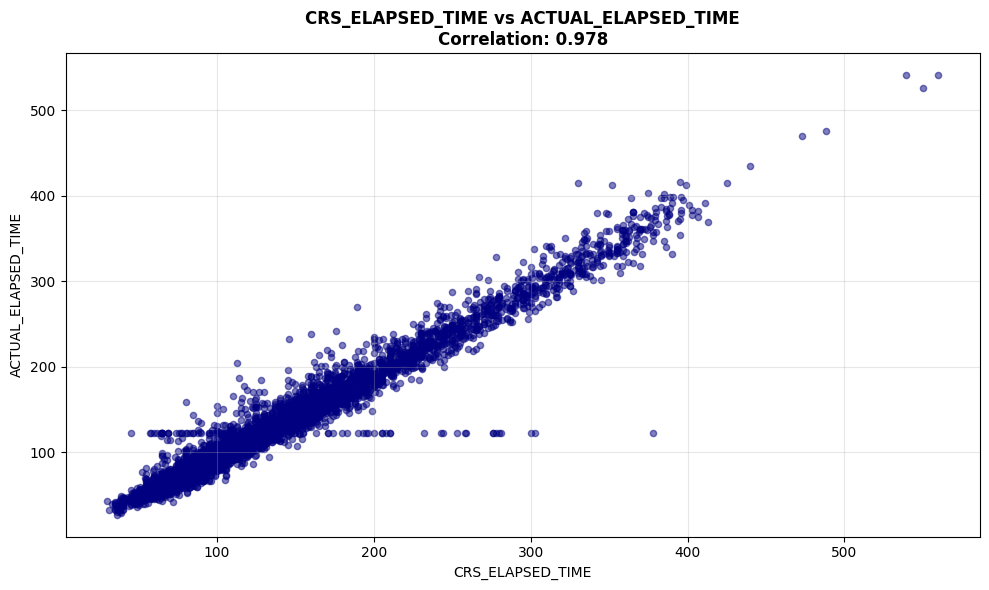

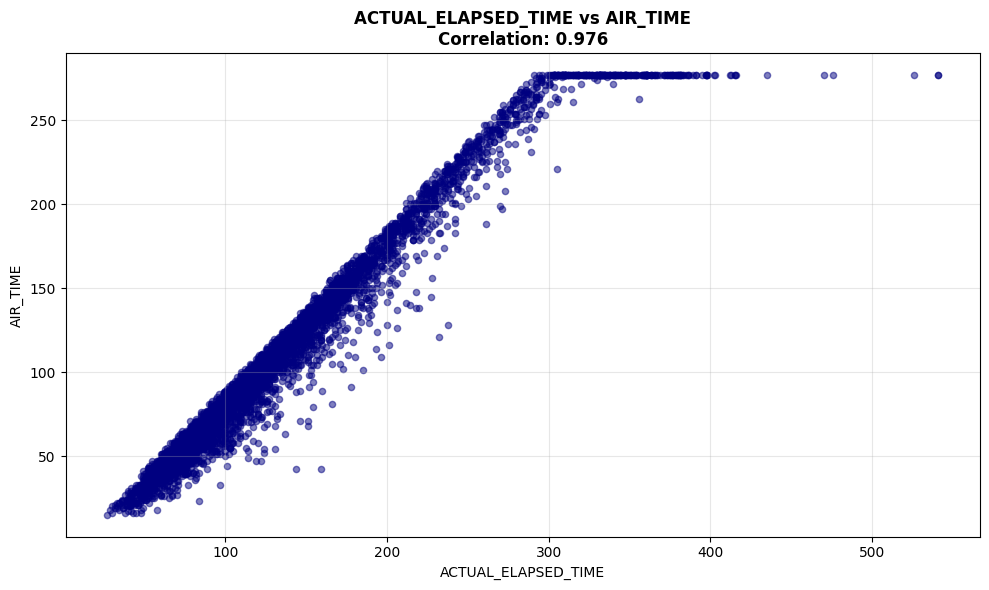

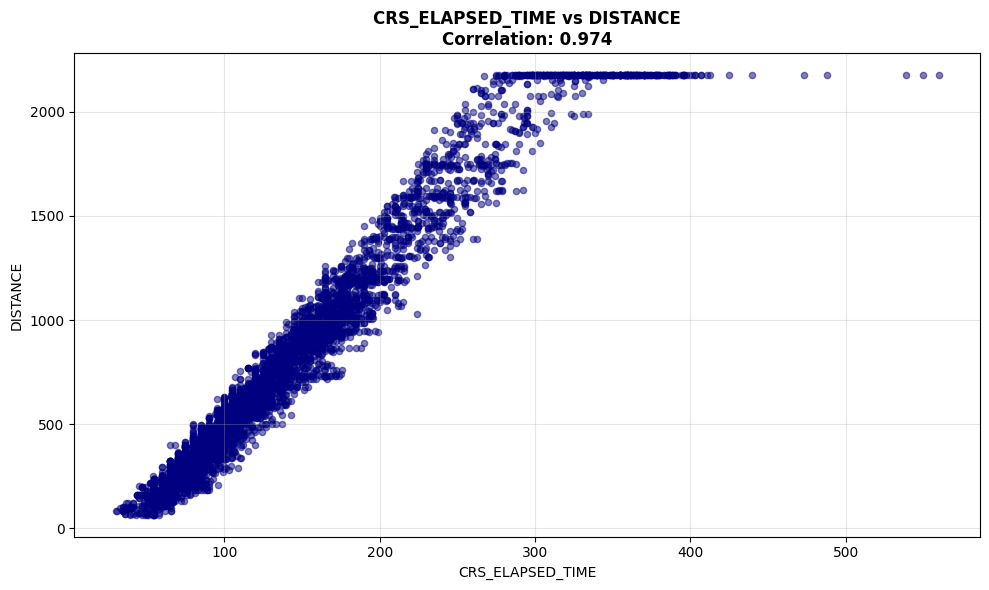

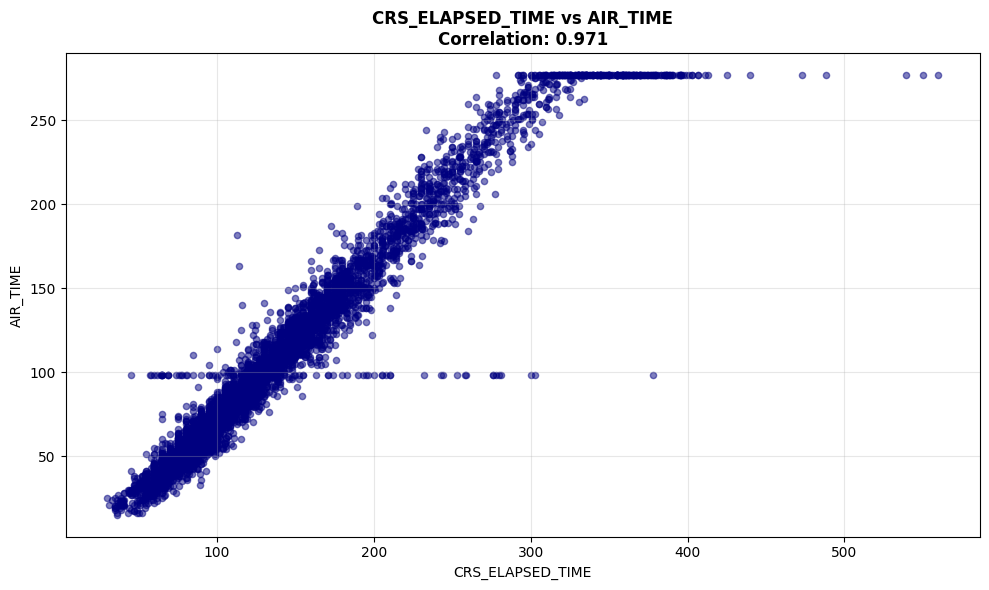

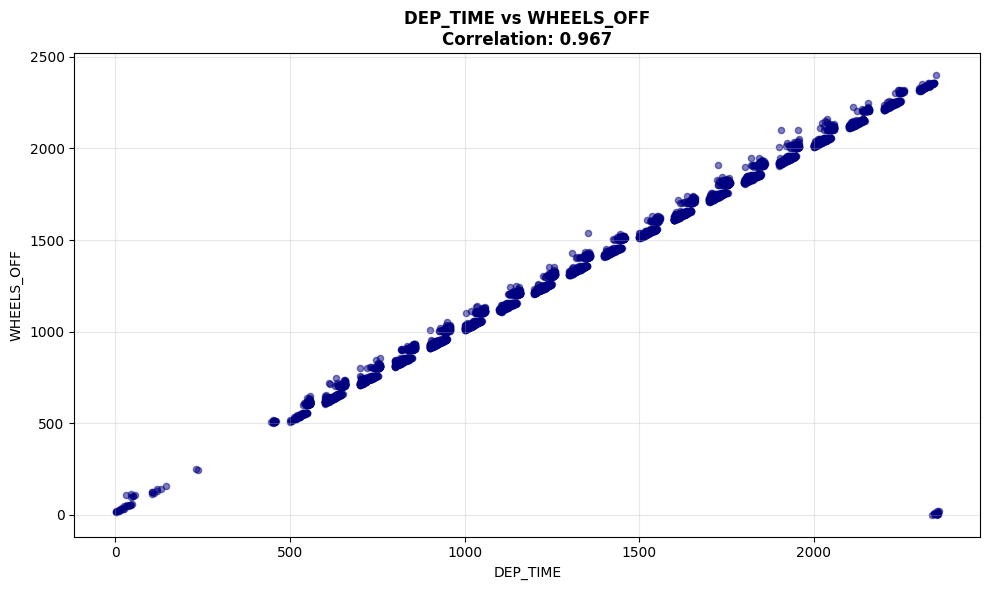

✓ Created 6 scatter plots!

✅ Bivariate Analysis Completed!


In [7]:
print("\nShape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("\n" + "="*70)
print(f"Numerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")

print("\nCreating Histograms...") #to show the distribution of each feature

for col in num_cols:
    plt.figure(figsize=(10, 6))

    sns.histplot(df[col].dropna(), kde=True, color='steelblue')

    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    mean_val = df[col].mean()
    median_val = df[col].median()
    plt.axvline(mean_val, color='red', linestyle='--',
                label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='--',
                label=f'Median: {median_val:.2f}')
    plt.legend()

    plt.tight_layout()
    plt.show()

print("✓ Histograms created!")

print("\nCreating Boxplots...") #to show distribution and identify outliers

for col in num_cols:
    plot_data = df[col].dropna()
    if plot_data.empty:
        print(f"  ⚠ Skipping boxplot for {col}: No valid data to plot after dropping NaNs.")
        continue

    plt.figure(figsize=(10, 6))

    sns.boxplot(x=plot_data, color='coral')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.xlabel(col)

    q1 = plot_data.quantile(0.25)
    q3 = plot_data.quantile(0.75)
    median = plot_data.median()

    stats_text = f'Q1: {q1:.2f}\nMedian: {median:.2f}\nQ3: {q3:.2f}'
    plt.text(0.02, 0.98, stats_text,
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7),
             fontsize=9)

    plt.tight_layout()
    plt.show()

print("✓ Boxplots created!")

print("\n✅ Univariate Analysis Completed!")

print("BIVARIATE ANALYSIS")

if len(num_cols) > 1:

    print("\nCreating Correlation Heatmap...") #to show relationship with all features

    plt.figure(figsize=(12, 8))

    corr_matrix = df[num_cols].corr()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) #used to high portion of correlation matrix to reduce redundant information

    # Red = positive correlation, Blue = negative correlation
    sns.heatmap(corr_matrix,
                mask=mask,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True)

    plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("✓ Correlation heatmap created!")

    # Print top correlations
    print("\nTop 5 Strongest Correlations:")
    print("-" * 60)

    # Extract all correlation pairs
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append({
                'Variable_1': corr_matrix.columns[i],
                'Variable_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

    # Sort by absolute correlation (strongest first)
    corr_df = pd.DataFrame(corr_pairs)
    corr_df['Abs_Corr'] = corr_df['Correlation'].abs()
    corr_df = corr_df.sort_values('Abs_Corr', ascending=False)

    # Show top 5
    for i, row in corr_df.head(5).iterrows():
        print(f"{row['Variable_1']} ↔ {row['Variable_2']}: {row['Correlation']:.3f}")


    print("\nCreating Scatter Plots...") #to show the relationship between pairs of features

    strong_corr = corr_df[corr_df['Abs_Corr'] > 0.5].head(6)

    if len(strong_corr) > 0:

        for _, row in strong_corr.iterrows():
            var1 = row['Variable_1']
            var2 = row['Variable_2']
            corr_val = row['Correlation']

            plot_data = df[[var1, var2]].dropna()

            if len(plot_data) > 5000:
                plot_data = plot_data.sample(5000, random_state=42)

            plt.figure(figsize=(10, 6))

            plt.scatter(plot_data[var1], plot_data[var2],
                       alpha=0.5, s=20, color='navy')
            plt.title(f'{var1} vs {var2}\nCorrelation: {corr_val:.3f}',
                     fontweight='bold')
            plt.xlabel(var1)
            plt.ylabel(var2)
            plt.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        print(f"✓ Created {len(strong_corr)} scatter plots!")

    else:
        print("⚠ No strong correlations found (threshold: 0.5)")
        print("  Creating scatter plots for top 4 pairs instead...")

        top_pairs = corr_df.head(4)

        for _, row in top_pairs.iterrows():
            var1 = row['Variable_1']
            var2 = row['Variable_2']
            corr_val = row['Correlation']

            plot_data = df[[var1, var2]].dropna()
            if len(plot_data) > 5000:
                plot_data = plot_data.sample(5000, random_state=42)

            plt.figure(figsize=(10, 6))

            plt.scatter(plot_data[var1], plot_data[var2],
                       alpha=0.5, s=20, color='navy')
            plt.title(f'{var1} vs {var2}\nCorrelation: {corr_val:.3f}',
                     fontweight='bold')
            plt.xlabel(var1)
            plt.ylabel(var2)
            plt.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        print("✓ Scatter plots created!")
    print("\n✅ Bivariate Analysis Completed!")

else:
    print("\n⚠ Need at least 2 numerical columns for bivariate analysis.")

INITIAL STATISTICAL FINDINGS

 GENERATING INITIAL STATISTICAL FINDINGS 


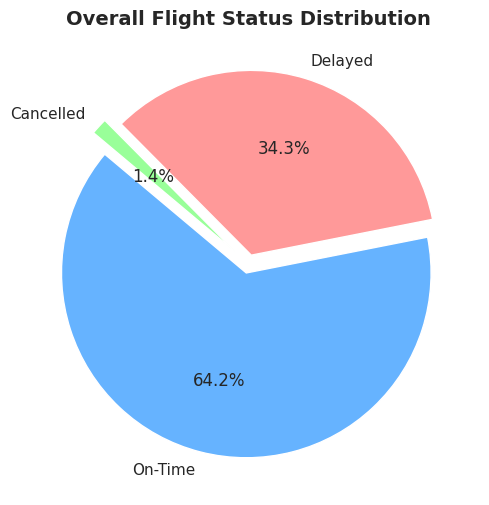

/tmp/ipykernel_25267/2493991554.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_delays.index, y=airline_delays.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_25267/2493991554.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delays.index, y=airport_delays.values, ax=axes[1], palette='magma')


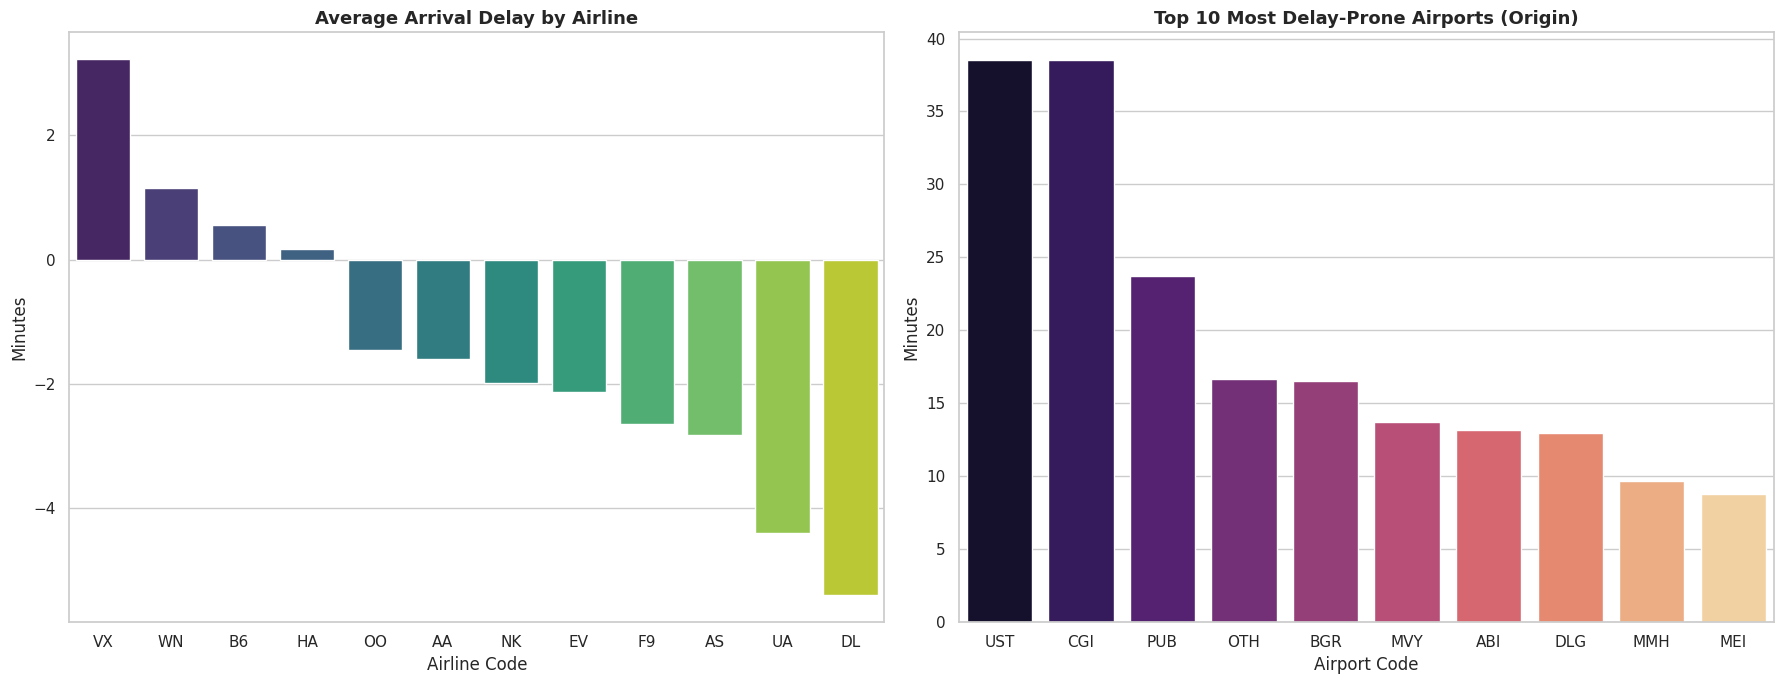

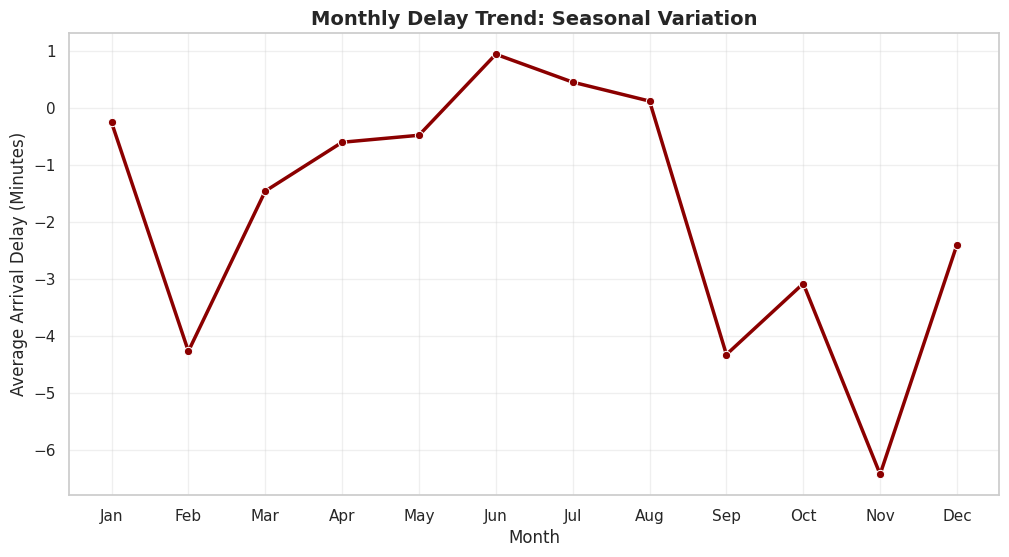

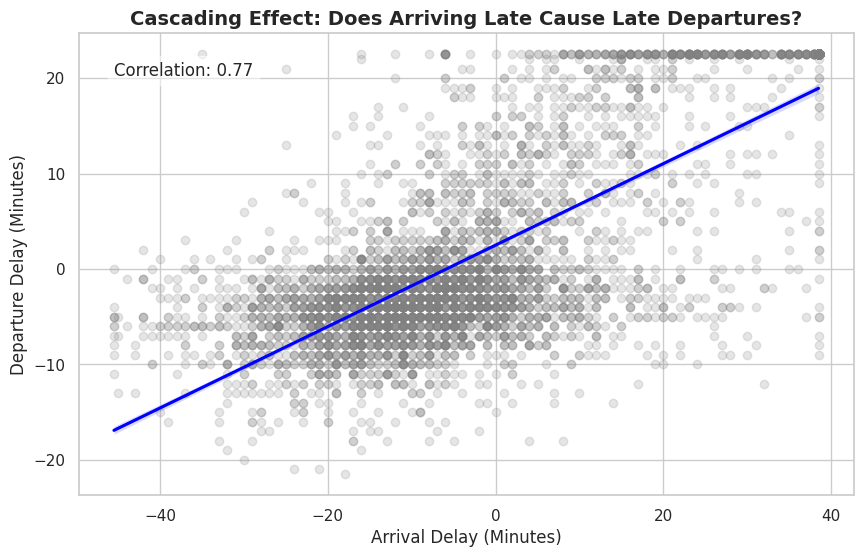


✓ Statistical Visualizations Complete!


In [8]:
sns.set_theme(style="whitegrid")

print(" GENERATING INITIAL STATISTICAL FINDINGS ")

# Defining status: Cancelled (1.0), Delayed (ARR_DELAY > 0), On-Time (ARR_DELAY <= 0)
cancelled_count = df['CANCELLED'].sum()
delayed_count = df[(df['CANCELLED'] == 0) & (df['ARR_DELAY'] > 0)].shape[0]
ontime_count = df[(df['CANCELLED'] == 0) & (df['ARR_DELAY'] <= 0)].shape[0]

labels = ['On-Time', 'Delayed', 'Cancelled']
sizes = [ontime_count, delayed_count, cancelled_count]
colors = ['#66b3ff', '#ff9999', '#99ff99'] # Soft blue, red, green

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0.05, 0.1))
plt.title('Overall Flight Status Distribution', fontsize=14, fontweight='bold')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Average Delay by Airline
airline_delays = df.groupby('OP_CARRIER')['ARR_DELAY'].mean().sort_values(ascending=False)
sns.barplot(x=airline_delays.index, y=airline_delays.values, ax=axes[0], palette='viridis')
axes[0].set_title('Average Arrival Delay by Airline', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Minutes')
axes[0].set_xlabel('Airline Code')

# Average Delay by Top 10 Airports
airport_delays = df.groupby('ORIGIN')['ARR_DELAY'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=airport_delays.index, y=airport_delays.values, ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Most Delay-Prone Airports (Origin)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Minutes')
axes[1].set_xlabel('Airport Code')

plt.tight_layout()
plt.show()

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['MONTH'] = df['FL_DATE'].dt.month

monthly_trend = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='darkred', linewidth=2.5)
plt.title('Monthly Delay Trend: Seasonal Variation', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Average Arrival Delay (Minutes)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 6))
sns.regplot(x='ARR_DELAY', y='DEP_DELAY', data=df.sample(min(5000, len(df))),
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'blue'})

plt.title('Cascading Effect: Does Arriving Late Cause Late Departures?', fontsize=14, fontweight='bold')
plt.xlabel('Arrival Delay (Minutes)')
plt.ylabel('Departure Delay (Minutes)')

# Correlation Calculation
corr_val = df['ARR_DELAY'].corr(df['DEP_DELAY'])
plt.text(df['ARR_DELAY'].min(), df['DEP_DELAY'].max()*0.9, f'Correlation: {corr_val:.2f}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()

print("\n✓ Statistical Visualizations Complete!")

# **WEEK 6 - FEATURE ENGINEERING**

/tmp/ipykernel_25267/4108840565.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_features['ARR_DELAY'].fillna(df_features['ARR_DELAY'].median(), inplace=True)
/tmp/ipykernel_25267/4108840565.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

Arrival Delay Skewness: 0.7461038215270969
Departure Delay Skewness: 0.9672247509434421


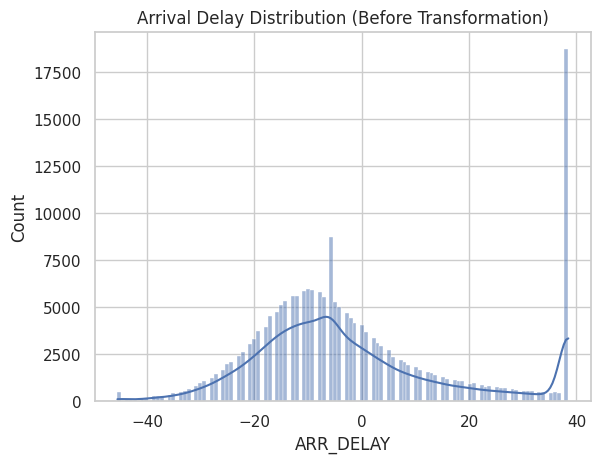

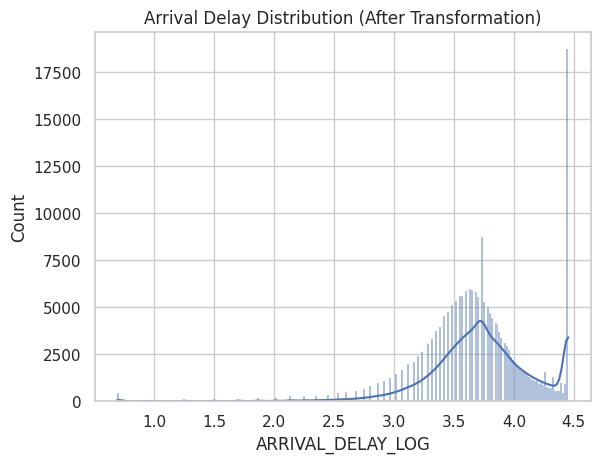

(200000, 670)
['FL_DATE', 'OP_CARRIER_FL_NUM', 'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY', 'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY', 'Unnamed: 27', 'MONTH', 'ARRIVAL_DELAY_LOG', 'DEPARTURE_DELAY_LOG', 'OP_CARRIER_AS', 'OP_CARRIER_B6', 'OP_CARRIER_DL', 'OP_CARRIER_EV', 'OP_CARRIER_F9', 'OP_CARRIER_HA', 'OP_CARRIER_NK', 'OP_CARRIER_OO', 'OP_CARRIER_UA', 'OP_CARRIER_VX', 'OP_CARRIER_WN', 'ORIGIN_ABI', 'ORIGIN_ABQ', 'ORIGIN_ABR', 'ORIGIN_ABY', 'ORIGIN_ACK', 'ORIGIN_ACT', 'ORIGIN_ACV', 'ORIGIN_ACY', 'ORIGIN_ADK', 'ORIGIN_ADQ', 'ORIGIN_AEX', 'ORIGIN_AGS', 'ORIGIN_AKN', 'ORIGIN_ALB', 'ORIGIN_ALO', 'ORIGIN_AMA', 'ORIGIN_ANC', 'ORIGIN_APN', 'ORIGIN_ASE', 'ORIGIN_ATL', 'ORIGIN_ATW', 'ORIGIN_AUS', 'ORIGIN_AVL', 'ORIGIN_AVP', 'ORIGIN_AZO', 'ORIGIN_BDL', '

In [9]:
from sklearn.preprocessing import RobustScaler

df_features = df.copy()

# --- Missing value imputation ---
df_features['ARR_DELAY'].fillna(df_features['ARR_DELAY'].median(), inplace=True)
df_features['DEP_DELAY'].fillna(df_features['DEP_DELAY'].median(), inplace=True)

# --- Skewness check ---
print("Arrival Delay Skewness:", df_features['ARR_DELAY'].skew())
print("Departure Delay Skewness:", df_features['DEP_DELAY'].skew())

# --- Plot before transformation ---
sns.histplot(df_features['ARR_DELAY'], kde=True)
plt.title("Arrival Delay Distribution (Before Transformation)")
plt.show()

# --- Log transformation (skewness correction) ---
df_features['ARRIVAL_DELAY_LOG'] = np.log1p(df_features['ARR_DELAY'] - df_features['ARR_DELAY'].min() + 1)
df_features['DEPARTURE_DELAY_LOG'] = np.log1p(df_features['DEP_DELAY'] - df_features['DEP_DELAY'].min() + 1)

# --- Plot after transformation ---
sns.histplot(df_features['ARRIVAL_DELAY_LOG'], kde=True)
plt.title("Arrival Delay Distribution (After Transformation)")
plt.show()

# --- One-Hot Encoding (correct approach) ---
df_features = pd.get_dummies(df_features, columns=['OP_CARRIER', 'ORIGIN', 'DEST'], drop_first=True)

# --- RobustScaler (correct approach) ---
scaler = RobustScaler()
scaled_features = scaler.fit_transform(df_features[['ARRIVAL_DELAY_LOG', 'DEPARTURE_DELAY_LOG']])
scaled_df = pd.DataFrame(scaled_features, columns=['ARRIVAL_DELAY_SCALED', 'DEPARTURE_DELAY_SCALED'])

# --- Final dataframe ---
df_final = pd.concat([df_features.reset_index(drop=True), scaled_df], axis=1)
print(df_final.shape)
print(df_final.columns.tolist())

# **WEEK 7 - PRINCIPAL COMPONENT ANALYSIS**

Columns in dataset:
 Index(['FL_DATE', 'OP_CARRIER', 'OP_CARRIER_FL_NUM', 'ORIGIN', 'DEST',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'CARRIER_DELAY',
       'WEATHER_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY',
       'Unnamed: 27'],
      dtype='object')

Using Features: ['DEP_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME', 'DISTANCE']

Selected Features: ['DEP_DELAY' 'TAXI_OUT' 'TAXI_IN']

Explained Variance Ratio:
[0.34968675 0.34403406 0.30627919]


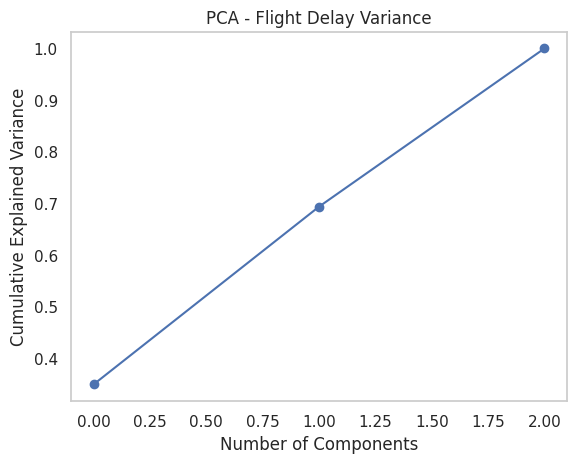


Reduced Data (First 5 rows):
        PC1       PC2  FLIGHT_STATUS
0  0.571266 -2.129565              0
1 -1.324029 -0.604075              0
2  1.760854 -1.596744              0
3  0.396015 -1.461244              0
4 -0.043775 -1.215992              1


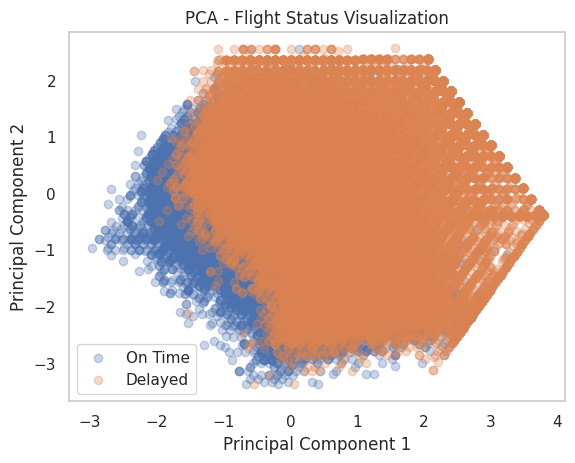

In [10]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("final_cleaned_dataset.csv")

print("Columns in dataset:\n", df.columns)

if 'ARR_DELAY' in df.columns:
    df['ARR_DELAY'] = df['ARR_DELAY'].fillna(df['ARR_DELAY'].median())

if 'DEP_DELAY' in df.columns:
    df['DEP_DELAY'] = df['DEP_DELAY'].fillna(df['DEP_DELAY'].median())

df['FLIGHT_STATUS'] = df['ARR_DELAY'].apply(lambda x: 1 if x > 0 else 0).astype(int)


possible_features = [
    'DEP_DELAY',
    'TAXI_OUT',
    'TAXI_IN',
    'AIR_TIME',
    'DISTANCE'
]

features = [col for col in possible_features if col in df.columns]

print("\nUsing Features:", features)

X = df[features].copy()
y = df['FLIGHT_STATUS']

X = X.fillna(X.median())

k = min(3, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X, y)

selected_features = np.array(features)[selector.get_support()]
print("\nSelected Features:", selected_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)


pca = PCA() # Initialize PCA here
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)

plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Flight Delay Variance')
plt.grid()
plt.show()

pca_final = PCA(n_components=2)
X_reduced = pca_final.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_reduced, columns=['PC1', 'PC2'])
pca_df['FLIGHT_STATUS'] = y.values

print("\nReduced Data (First 5 rows):")
print(pca_df.head())

plt.figure()

subset0 = pca_df[pca_df['FLIGHT_STATUS'] == 0]
subset1 = pca_df[pca_df['FLIGHT_STATUS'] == 1]

plt.scatter(subset0['PC1'], subset0['PC2'], alpha=0.3, label='On Time')
plt.scatter(subset1['PC1'], subset1['PC2'], alpha=0.3, label='Delayed')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - Flight Status Visualization')
plt.legend()
plt.grid()
plt.show()